In [ ]:
import pickle
import math
import networkx as nx
from collections import defaultdict

# ============================================================
# PARAMETERS
# ============================================================

ALPHA  = 1.0    # α — energy (ΔG) scaling weight
GAMMA  = 0.7    # γ — restriction (competition) scaling weight
BETA   = 1.0    # β — sharpness of exponential
LAMBDA = 2.0    # λ — robustness boost strength
DELTA  = 2.0    # δ — viability tolerance (same units as DG)
RT     = 0.593  # kcal/mol at 298K  |  use 2.479 if DG is in kJ/mol

# ============================================================
# PATHS
# ============================================================

GRAPH_LOAD_PATH   = "reaction_graph_molecule_centric.pkl"
GRAPH_SAVE_PATH   = "reaction_graph_weighted.pkl"
GRAPHML_SAVE_PATH = "reaction_graph_weighted.graphml"

# ============================================================
# LOAD
# ============================================================

print("Loading graph...")
with open(GRAPH_LOAD_PATH, "rb") as f:
    G = pickle.load(f)
print(f"Nodes : {G.number_of_nodes():,}")
print(f"Edges : {G.number_of_edges():,}")

# ============================================================
# STEP 1 — PER-NODE AGGREGATES (needed before weight calc)
#
# For each source node u, compute:
#   k_uv    = exp(-DG_uv / RT)           rate constant (Eyring, proportional form)
#   Σ k_i   = sum of k over all out-edges from u   → for R_uv
#   ΔG_min  = min DG over all out-edges from u      → for r(u,v)
# ============================================================

print("\nComputing per-node aggregates...")

node_sum_k  = defaultdict(float)
node_DG_min = defaultdict(lambda: math.inf)

for u, v, key, attrs in G.edges(keys=True, data=True):
    k_uv = math.exp(-attrs["DG"] / RT)
    G[u][v][key]["_k"] = k_uv                          # cache for step 2
    node_sum_k[u]     += k_uv
    node_DG_min[u]     = min(node_DG_min[u], attrs["DG"])

# ============================================================
# STEP 2 — ASSIGN EDGE WEIGHTS
#
# R_uv  = Σ_i k_i / k_uv
#           large when k_uv is weak vs competitors → penalty
#
# r_uv  = 1  if DG_uv ≤ ΔG_min(u) + δ  (viable / near-best edge)
#         0  otherwise
#
# C_uv  = α·ΔG_uv + γ·R_uv             (base cost)
#
# w_uv  = exp(-β · C_uv) · (1 + λ · r_uv)   ← FINAL WEIGHT
# ============================================================

print("Assigning edge weights...")

for u, v, key, attrs in G.edges(keys=True, data=True):

    DG_uv  = attrs["DG"]
    k_uv   = attrs["_k"]
    sum_k  = node_sum_k[u]
    DG_min = node_DG_min[u]

    raw_R_uv = sum_k / k_uv if k_uv != 0.0 else float("inf")

    R_uv = math.log(raw_R_uv) if raw_R_uv > 0 else 0
    r_uv = 1 if DG_uv <= DG_min + DELTA else 0
    C_uv = ALPHA * DG_uv + GAMMA * R_uv
    w_uv = math.exp(-BETA * C_uv) * (1.0 + LAMBDA * r_uv)

    G[u][v][key]["weight"]      = w_uv   # ← final weight (your formula)
    G[u][v][key]["restriction"] = R_uv
    G[u][v][key]["robustness"]  = r_uv
    G[u][v][key]["cost"]        = C_uv
    del G[u][v][key]["_k"]

# ============================================================
# SUMMARY STATS
# ============================================================

weights = [d["weight"] for _, _, d in G.edges(data=True)]
print(f"\nWeight stats over {len(weights):,} edges:")
print(f"  min  : {min(weights):.6e}")
print(f"  max  : {max(weights):.6e}")
print(f"  mean : {sum(weights)/len(weights):.6e}")

# ============================================================
# SAVE
# ============================================================

print("\nSaving weighted graph (pickle)...")
with open(GRAPH_SAVE_PATH, "wb") as f:
    pickle.dump(G, f)
print("Saved:", GRAPH_SAVE_PATH)

print("Saving weighted graph (GraphML)...")

def make_graphml_safe(G):
    G_safe = nx.MultiDiGraph()
    for n, attrs in G.nodes(data=True):
        safe = {k: str(v) if isinstance(v, (list, dict, tuple)) else v for k, v in attrs.items()}
        G_safe.add_node(n, **safe)
    for u, v, k, attrs in G.edges(keys=True, data=True):
        safe = {k2: str(v2) if isinstance(v2, (list, dict, tuple)) else v2 for k2, v2 in attrs.items()}
        G_safe.add_edge(u, v, key=k, **safe)
    return G_safe

nx.write_graphml(make_graphml_safe(G), GRAPHML_SAVE_PATH)
print("Saved:", GRAPHML_SAVE_PATH)
print("\nDONE.")

Loading graph...
Nodes : 123,174
Edges : 770,844

Computing per-node aggregates...
Assigning edge weights...

Weight stats over 770,844 edges:
  min  : 7.695984e-158
  max  : 2.983105e+00
  mean : 6.737903e-04

Saving weighted graph (pickle)...
Saved: reaction_graph_weighted.pkl
Saving weighted graph (GraphML)...
Saved: reaction_graph_weighted.graphml

DONE.


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.3 MB/s eta 0:00:00


In [ ]:
import pickle
import numpy as np
import networkx as nx
import optuna
import math

# ============================================================
# PATHS
# ============================================================
GRAPH_LOAD_PATH = "reaction_graph_weighted.pkl"

# ============================================================
# LOAD DATA
# ============================================================
print("Loading weighted graph...")
with open(GRAPH_LOAD_PATH, "rb") as f:
    G = pickle.load(f)

# Extract raw weights into a numpy array for speed
# We work with log-weights to maintain precision for 10^-158 values
edges = list(G.edges(keys=True, data=True))
raw_weights = np.array([d['weight'] for u, v, k, d in edges])
log_raw_weights = np.log(raw_weights + 1e-300) # Natural log

# Pre-calculate node indices for transition probability calculation
# Mapping nodes to integers to handle sparse-like math
node_list = list(G.nodes())
node_idx = {node: i for i, node in enumerate(node_list)}
edge_sources = np.array([node_idx[u] for u, v, k, d in edges])

# ============================================================
# OPTUNA OBJECTIVE
# ============================================================
# Research Basis: Burda et al. (2009) - Maximize Shannon Entropy
# To prevent "Localization" in the reaction graph.
# ============================================================

def objective(trial):
    # Suggest a Temperature (tau).
    # High tau = Hot (Uniform/Entropic), Low tau = Cold (Deterministic)
    tau = trial.suggest_float("tau", 0.01, 20.0)

    # 1. Apply Temperature Scaling in Log Space: log(w) / tau
    # We subtract the max log weight per node for numerical stability (Softmax trick)
    scaled_log_w = log_raw_weights / tau

    # 2. Calculate Transition Probabilities P_uv
    # P_uv = exp(scaled_log_w) / sum(exp(scaled_log_w)_neighbors)
    exp_w = np.exp(scaled_log_w - np.max(scaled_log_w)) # Stable exponentiation

    # Sum weights per source node
    node_sums = np.zeros(len(node_list))
    np.add.at(node_sums, edge_sources, exp_w)

    # Compute P_uv
    # Avoid division by zero for isolated nodes
    p_uv = exp_w / (node_sums[edge_sources] + 1e-20)

    # 3. Calculate Shannon Entropy: H = -sum(P * log(P))
    # We ignore P=0 to avoid log(0)
    safe_p = p_uv[p_uv > 0]
    entropy = -np.sum(safe_p * np.log(safe_p))

    # We maximize entropy to ensure the random walk explores the manifold
    return entropy

# ============================================================
# RUN OPTIMIZATION
# ============================================================
print("\nStarting Optuna optimization for Temperature Scaling...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best_tau = study.best_params["tau"]
print(f"\nOptimal Temperature (tau) found: {best_tau:.4f}")

# ============================================================
# APPLY FINAL SCALING & PRINT DISTRIBUTION
# ============================================================
final_log_w = log_raw_weights / best_tau
final_weights = np.exp(final_log_w - np.max(final_log_w))

# Normalize to [0, 1] range for readability
final_weights = final_weights / np.max(final_weights)

print("\n--- FINAL WEIGHT DISTRIBUTION (T-SCALED) ---")
print(f"Paper Reference: Localization of the Maximum Entropy Random Walk (Burda et al.)")
print(f"Optimization Goal: Maximize Network Shannon Entropy")

# Log10 stats for final distribution visualization
log10_final = np.log10(final_weights + 1e-300)

stats = {
    "Dominant (> 10^-2)": np.sum(final_weights > 0.01),
    "Visible (10^-8 to 10^-2)": np.sum((final_weights <= 0.01) & (final_weights > 1e-8)),
    "Trace (10^-15 to 10^-8)": np.sum((final_weights <= 1e-8) & (final_weights > 1e-15)),
    "Still Invisible (< 10^-15)": np.sum(final_weights <= 1e-15)
}

for label, count in stats.items():
    pct = (count / len(final_weights)) * 100
    print(f"{label:30} : {count:8,} edges ({pct:6.2f}%)")

print(f"\nMin Weight: {np.min(final_weights):.2e}")
print(f"Max Weight: {np.max(final_weights):.2e}")
print(f"Mean Weight: {np.mean(final_weights):.2e}")

# Apply to graph and save
for i, (u, v, k, d) in enumerate(edges):
    G[u][v][k]['weight'] = float(final_weights[i])

with open("reaction_graph_t_scaled.pkl", "wb") as f:
    pickle.dump(G, f)
print("\nSaved: reaction_graph_t_scaled.pkl")


Loading weighted graph...


[I 2026-04-02 20:51:50,282] A new study created in memory with name: no-name-6b9e59aa-6a0e-4fd1-9a37-97d776982831
[I 2026-04-02 20:51:50,333] Trial 0 finished with value: 62300.63081772495 and parameters: {'tau': 15.901559669708128}. Best is trial 0 with value: 62300.63081772495.
[I 2026-04-02 20:51:50,388] Trial 1 finished with value: 61174.41736616533 and parameters: {'tau': 14.613300625531757}. Best is trial 0 with value: 62300.63081772495.
[I 2026-04-02 20:51:50,431] Trial 2 finished with value: 54584.79856084057 and parameters: {'tau': 8.537213948470713}. Best is trial 0 with value: 62300.63081772495.
[I 2026-04-02 20:51:50,455] Trial 3 finished with value: 56857.19716869846 and parameters: {'tau': 10.393570333783824}. Best is trial 0 with value: 62300.63081772495.
[I 2026-04-02 20:51:50,474] Trial 4 finished with value: 54723.61161288494 and parameters: {'tau': 8.644311076931793}. Best is trial 0 with value: 62300.63081772495.



Starting Optuna optimization for Temperature Scaling...


[I 2026-04-02 20:51:50,514] Trial 5 finished with value: 64901.722822643285 and parameters: {'tau': 19.286383055907148}. Best is trial 5 with value: 64901.722822643285.
[I 2026-04-02 20:51:50,560] Trial 6 finished with value: 58950.24731153217 and parameters: {'tau': 12.312950625385094}. Best is trial 5 with value: 64901.722822643285.
[I 2026-04-02 20:51:50,592] Trial 7 finished with value: 60961.904592458406 and parameters: {'tau': 14.380248067432026}. Best is trial 5 with value: 64901.722822643285.
[I 2026-04-02 20:51:50,650] Trial 8 finished with value: 64734.84855666253 and parameters: {'tau': 19.048938925031813}. Best is trial 5 with value: 64901.722822643285.
[I 2026-04-02 20:51:50,703] Trial 9 finished with value: 61321.97698032225 and parameters: {'tau': 14.776921925150583}. Best is trial 5 with value: 64901.722822643285.
[I 2026-04-02 20:51:50,760] Trial 10 finished with value: 41896.7918049617 and parameters: {'tau': 2.3069324242795757}. Best is trial 5 with value: 64901.7228


Optimal Temperature (tau) found: 19.9930

--- FINAL WEIGHT DISTRIBUTION (T-SCALED) ---
Paper Reference: Localization of the Maximum Entropy Random Walk (Burda et al.)
Optimization Goal: Maximize Network Shannon Entropy
Dominant (> 10^-2)             :  276,456 edges ( 35.86%)
Visible (10^-8 to 10^-2)       :  494,388 edges ( 64.14%)
Trace (10^-15 to 10^-8)        :        0 edges (  0.00%)
Still Invisible (< 10^-15)     :        0 edges (  0.00%)

Min Weight: 1.31e-08
Max Weight: 1.00e+00
Mean Weight: 3.11e-02

Saved: reaction_graph_t_scaled.pkl


In [ ]:
import pickle
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
import time

# ============================================================
# CONFIG — change path to match yours
# ============================================================
GRAPH_PATH = "reaction_graph_t_scaled.pkl"   # original graph

def elapsed(start):
    s = time.time() - start
    return f"{s:.1f}s" if s < 60 else f"{s/60:.1f}min"

t0 = time.time()

# ============================================================
# LOAD
# ============================================================
print("=" * 60)
print("LOADING GRAPH")
print("=" * 60)
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

nodes = list(G.nodes())
N     = len(nodes)
E     = G.number_of_edges()
print(f"  Nodes : {N:,}  |  Edges : {E:,}  |  Loaded in {elapsed(t0)}")

# ============================================================
# 1. BASIC DEGREE STATS
# ============================================================
print("\n" + "=" * 60)
print("1. DEGREE STATISTICS")
print("=" * 60)

in_deg  = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])
tot_deg = in_deg + out_deg

print(f"  In-degree  — mean: {in_deg.mean():.2f}  median: {np.median(in_deg):.0f}  "
      f"max: {in_deg.max()}  zeros: {(in_deg==0).sum():,}")
print(f"  Out-degree — mean: {out_deg.mean():.2f}  median: {np.median(out_deg):.0f}  "
      f"max: {out_deg.max()}  zeros: {(out_deg==0).sum():,}")
print(f"  Isolated (in=0 AND out=0): {((in_deg==0)&(out_deg==0)).sum():,}")
print(f"  Pure sinks  (out=0, in>0): {((out_deg==0)&(in_deg>0)).sum():,}")
print(f"  Pure sources(in=0, out>0): {((in_deg==0)&(out_deg>0)).sum():,}")

# ============================================================
# 2. WEAKLY CONNECTED COMPONENTS
# ============================================================
print("\n" + "=" * 60)
print("2. WEAKLY CONNECTED COMPONENTS (WCCs)")
print("=" * 60)

t_wcc = time.time()
wccs  = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print(f"  Total WCCs       : {len(wccs):,}  [{elapsed(t_wcc)}]")
print(f"  Largest WCC      : {len(wccs[0]):,} nodes  ({100*len(wccs[0])/N:.1f}%)")
if len(wccs) > 1:
    print(f"  2nd largest WCC  : {len(wccs[1]):,} nodes")
if len(wccs) > 2:
    print(f"  3rd largest WCC  : {len(wccs[2]):,} nodes")

# Size distribution of WCCs
wcc_sizes = [len(w) for w in wccs]
size_counts = Counter(wcc_sizes)
print(f"\n  WCC size distribution:")
print(f"    Size 1  (isolated) : {size_counts.get(1,0):>8,}")
print(f"    Size 2-5           : {sum(v for k,v in size_counts.items() if 2<=k<=5):>8,}  WCCs")
print(f"    Size 6-10          : {sum(v for k,v in size_counts.items() if 6<=k<=10):>8,}  WCCs")
print(f"    Size 11-50         : {sum(v for k,v in size_counts.items() if 11<=k<=50):>8,}  WCCs")
print(f"    Size 51-500        : {sum(v for k,v in size_counts.items() if 51<=k<=500):>8,}  WCCs")
print(f"    Size 501-5000      : {sum(v for k,v in size_counts.items() if 501<=k<=5000):>8,}  WCCs")
print(f"    Size >5000         : {sum(v for k,v in size_counts.items() if k>5000):>8,}  WCCs")

# Nodes by WCC size bucket
nodes_in_singleton = size_counts.get(1, 0)
nodes_in_small     = sum(k*v for k,v in size_counts.items() if 2<=k<=10)
nodes_in_medium    = sum(k*v for k,v in size_counts.items() if 11<=k<=500)
nodes_in_large     = sum(k*v for k,v in size_counts.items() if k>500)
print(f"\n  NODES by WCC size:")
print(f"    In singleton WCCs  (size=1)   : {nodes_in_singleton:>8,}  ({100*nodes_in_singleton/N:.1f}%)")
print(f"    In tiny WCCs       (size 2-10): {nodes_in_small:>8,}  ({100*nodes_in_small/N:.1f}%)")
print(f"    In medium WCCs     (size11-500): {nodes_in_medium:>8,}  ({100*nodes_in_medium/N:.1f}%)")
print(f"    In large WCCs      (size>500) : {nodes_in_large:>8,}  ({100*nodes_in_large/N:.1f}%)")

# ============================================================
# 3. STRONGLY CONNECTED COMPONENTS
# ============================================================
print("\n" + "=" * 60)
print("3. STRONGLY CONNECTED COMPONENTS (SCCs)")
print("=" * 60)

t_scc = time.time()
sccs  = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
print(f"  Total SCCs       : {len(sccs):,}  [{elapsed(t_scc)}]")
print(f"  Largest SCC      : {len(sccs[0]):,} nodes  ({100*len(sccs[0])/N:.1f}%)")
if len(sccs) > 1:
    print(f"  2nd largest SCC  : {len(sccs[1]):,} nodes")

scc_sizes   = [len(s) for s in sccs]
scc_counts  = Counter(scc_sizes)
print(f"\n  SCC size distribution:")
print(f"    Size 1 (no cycle)  : {scc_counts.get(1,0):>8,}")
print(f"    Size 2-5           : {sum(v for k,v in scc_counts.items() if 2<=k<=5):>8,}  SCCs")
print(f"    Size 6-50          : {sum(v for k,v in scc_counts.items() if 6<=k<=50):>8,}  SCCs")
print(f"    Size >50           : {sum(v for k,v in scc_counts.items() if k>50):>8,}  SCCs")

# ============================================================
# 4. REACHABILITY FROM/TO THE GIANT WCC
# ============================================================
print("\n" + "=" * 60)
print("4. REACHABILITY ANALYSIS")
print("=" * 60)

giant_wcc   = wccs[0]
outside_wcc = set(nodes) - giant_wcc
print(f"  Giant WCC size   : {len(giant_wcc):,}")
print(f"  Outside giant WCC: {len(outside_wcc):,}")

# Count edges between giant WCC and outside
edges_giant_to_outside = 0
edges_outside_to_giant = 0
edges_outside_internal = 0

t_edge = time.time()
for u, v in G.edges():
    u_in = u in giant_wcc
    v_in = v in giant_wcc
    if u_in and not v_in:
        edges_giant_to_outside += 1
    elif not u_in and v_in:
        edges_outside_to_giant += 1
    elif not u_in and not v_in:
        edges_outside_internal += 1

print(f"\n  Edge cross-analysis [{elapsed(t_edge)}]:")
print(f"    Giant->Outside   : {edges_giant_to_outside:>8,}")
print(f"    Outside->Giant   : {edges_outside_to_giant:>8,}")
print(f"    Outside->Outside : {edges_outside_internal:>8,}")
print(f"    Inside giant     : {E - edges_giant_to_outside - edges_outside_to_giant - edges_outside_internal:>8,}")

# ============================================================
# 5. OUTSIDE-GIANT WCC STRUCTURE
# ============================================================
print("\n" + "=" * 60)
print("5. OUTSIDE-GIANT SUBGRAPH STRUCTURE")
print("=" * 60)

G_out  = G.subgraph(outside_wcc)
wccs_out = sorted(nx.weakly_connected_components(G_out), key=len, reverse=True)
print(f"  WCCs outside giant : {len(wccs_out):,}")

if wccs_out:
    sizes_out = [len(w) for w in wccs_out]
    sc_out    = Counter(sizes_out)
    print(f"  Largest outside WCC: {sizes_out[0]:,} nodes")
    print(f"  Size distribution:")
    print(f"    Size 1  : {sc_out.get(1,0):>8,}")
    print(f"    Size 2-5: {sum(v for k,v in sc_out.items() if 2<=k<=5):>8,}  WCCs")
    print(f"    Size 6-20:{sum(v for k,v in sc_out.items() if 6<=k<=20):>8,}  WCCs")
    print(f"    Size >20: {sum(v for k,v in sc_out.items() if k>20):>8,}  WCCs")

    # Internal edges in outside components
    out_edges = G_out.number_of_edges()
    print(f"\n  Total edges within outside-giant nodes: {out_edges:,}")
    print(f"  Avg edges per outside-node             : {out_edges/len(outside_wcc):.3f}")

    # How many outside WCCs have at least one directed edge internally?
    has_directed = sum(1 for w in wccs_out
                       if G_out.subgraph(w).number_of_edges() > 0)
    print(f"  Outside WCCs with >=1 directed edge    : {has_directed:,} / {len(wccs_out):,}")

# ============================================================
# 6. WEIGHT DISTRIBUTION
# ============================================================
print("\n" + "=" * 60)
print("6. EDGE WEIGHT DISTRIBUTION")
print("=" * 60)

weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
print(f"  Min    : {weights.min():.3e}")
print(f"  Max    : {weights.max():.3e}")
print(f"  Mean   : {weights.mean():.3e}")
print(f"  Median : {np.median(weights):.3e}")
print(f"  Weights < 1e-6  : {(weights < 1e-6).sum():,}  ({100*(weights<1e-6).mean():.1f}%)")
print(f"  Weights < 1e-4  : {(weights < 1e-4).sum():,}  ({100*(weights<1e-4).mean():.1f}%)")
print(f"  Weights >= 0.01 : {(weights >= 0.01).sum():,}  ({100*(weights>=0.01).mean():.1f}%)")
print(f"  Weights == 1.0  : {(weights == 1.0).sum():,}  ({100*(weights==1.0).mean():.1f}%)")

# ============================================================
# 7. VERDICT
# ============================================================
print("\n" + "=" * 60)
print("7. VERDICT & RECOMMENDATIONS")
print("=" * 60)

frac_giant   = len(giant_wcc) / N
frac_outside = len(outside_wcc) / N
outside_has_edges = edges_outside_internal > 0

print(f"  Giant WCC fraction   : {100*frac_giant:.1f}%")
print(f"  Outside fraction     : {100*frac_outside:.1f}%")
print(f"  Outside has edges    : {outside_has_edges}")
print(f"  Outside->Giant edges : {edges_outside_to_giant:,}")

print(f"\n  DIAGNOSIS:")
if frac_giant > 0.5:
    print(f"  [!] Graph has a dominant giant component ({100*frac_giant:.0f}% of nodes).")
if frac_outside > 0.3:
    print(f"  [!] {100*frac_outside:.0f}% of nodes are OUTSIDE the giant WCC.")
    print(f"      These nodes form fragmented small components.")
if edges_outside_to_giant > 0:
    print(f"  [!] {edges_outside_to_giant:,} edges go from outside INTO the giant.")
    print(f"      Outside nodes can reach giant but giant cannot return to them.")
    print(f"      => These are TRUE SINKS in the directed sense.")
if edges_outside_internal == 0:
    print(f"  [!] Outside-giant nodes have NO edges among themselves.")
    print(f"      Every outside node is completely isolated from other outside nodes.")
    print(f"      TPT cannot find pairs among them — they are dead ends.")
else:
    print(f"  [OK] {edges_outside_internal:,} edges exist within outside-giant nodes.")
    print(f"       Some pairs may be extractable from these.")

print(f"\n  RECOMMENDATION:")
if edges_outside_internal < 1000:
    print(f"  The 46% outside nodes are structurally isolated sinks/sources.")
    print(f"  They have no internal connectivity — TPT is mathematically")
    print(f"  meaningless for them individually.")
    print(f"  OPTIONS:")
    print(f"    A) Accept 54% coverage — it reflects the true graph structure.")
    print(f"    B) Use WALKS only (no TPT) for outside nodes — they still get")
    print(f"       embeddings via random walks even without q+/f+.")
    print(f"    C) Increase MAX_PAIRS and let greedy pick more giant-basin pairs")
    print(f"       with diverse chemistry (different src/tgt inside the giant).")
    print(f"    D) Pre-filter graph to giant WCC only before running TPT.")
else:
    print(f"  Outside nodes have internal edges — investigate further.")

print(f"\n  Total analysis time: {elapsed(t0)}")
print("DONE.")

LOADING GRAPH
  Nodes : 123,174  |  Edges : 770,844  |  Loaded in 7.7s

1. DEGREE STATISTICS
  In-degree  — mean: 6.26  median: 2  max: 12253  zeros: 0
  Out-degree — mean: 6.26  median: 2  max: 12253  zeros: 0
  Isolated (in=0 AND out=0): 0
  Pure sinks  (out=0, in>0): 0
  Pure sources(in=0, out>0): 0

2. WEAKLY CONNECTED COMPONENTS (WCCs)
  Total WCCs       : 25,910  [14.6s]
  Largest WCC      : 66,579 nodes  (54.1%)
  2nd largest WCC  : 12 nodes
  3rd largest WCC  : 12 nodes

  WCC size distribution:
    Size 1  (isolated) :    1,060
    Size 2-5           :   24,668  WCCs
    Size 6-10          :      174  WCCs
    Size 11-50         :        7  WCCs
    Size 51-500        :        0  WCCs
    Size 501-5000      :        0  WCCs
    Size >5000         :        1  WCCs

  NODES by WCC size:
    In singleton WCCs  (size=1)   :    1,060  (0.9%)
    In tiny WCCs       (size 2-10):   55,455  (45.0%)
    In medium WCCs     (size11-500):       80  (0.1%)
    In large WCCs      (size>500) 

Loading reaction_graph_t_scaled.pkl...


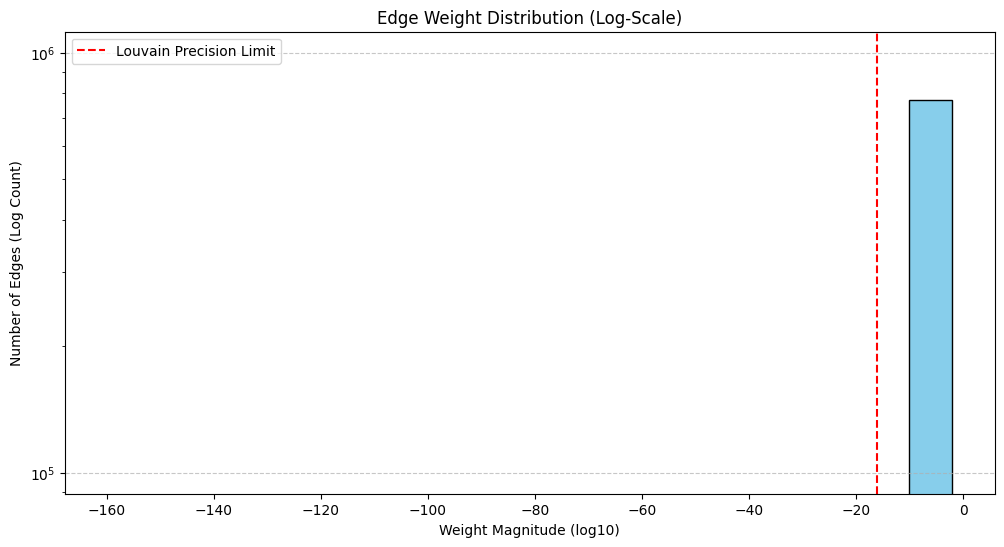


--- WEIGHT DOMINANCE SUMMARY ---
Total Edges: 770,844
Dominant (10^-2 to 10^1)       :  276,456 edges ( 35.86%)
Active (10^-10 to 10^-2)       :  494,388 edges ( 64.14%)
Trace (10^-20 to 10^-10)       :        0 edges (  0.00%)
Numerically Dead (< 10^-20)    :        0 edges (  0.00%)


In [ ]:
import pickle
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1. LOAD THE GRAPH
GRAPH_PATH = "reaction_graph_t_scaled.pkl"

print(f"Loading {GRAPH_PATH}...")
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

# 2. EXTRACT WEIGHTS
# Since it's a MultiDiGraph, we iterate through all edges
weights = [d['weight'] for u, v, k, d in G.edges(keys=True, data=True)]
weights = np.array(weights)

# 3. CALCULATE LOG-DISTRIBUTION
# We use log10 to see the "orders of magnitude"
# We use a small epsilon to avoid log(0) if any weights are exactly 0
log_weights = np.log10(weights + 1e-300)

# 4. BINNING THE DATA
bins = np.arange(-160, 5, 10) # Bins every 10 orders of magnitude
hist, bin_edges = np.histogram(log_weights, bins=bins)

# 5. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.bar(bin_edges[:-1], hist, width=8, align='edge', color='skyblue', edgecolor='black')
plt.yscale('log') # Log scale for the count to see small groups
plt.title("Edge Weight Distribution (Log-Scale)")
plt.xlabel("Weight Magnitude (log10)")
plt.ylabel("Number of Edges (Log Count)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical line for the Louvain "Precision Barrier"
# Anything 16-17 orders of magnitude below the max is invisible to Louvain
max_log = np.max(log_weights)
plt.axvline(x=max_log - 16, color='red', linestyle='--', label='Louvain Precision Limit')
plt.legend()

plt.show()

# 6. TEXT SUMMARY
print("\n--- WEIGHT DOMINANCE SUMMARY ---")
total_edges = len(weights)
print(f"Total Edges: {total_edges:,}")

# Define Regimes
regimes = {
    "Dominant (10^-2 to 10^1)": np.sum(weights >= 1e-2),
    "Active (10^-10 to 10^-2)": np.sum((weights < 1e-2) & (weights >= 1e-10)),
    "Trace (10^-20 to 10^-10)": np.sum((weights < 1e-10) & (weights >= 1e-20)),
    "Numerically Dead (< 10^-20)": np.sum(weights < 1e-20)
}

for name, count in regimes.items():
    percentage = (count / total_edges) * 100
    print(f"{name:30} : {count:8,} edges ({percentage:6.2f}%)")

In [ ]:
!pip install gensim smart_open

In [ ]:
!pip uninstall -y smart_open gensim

Found existing installation: smart_open 7.5.1
Uninstalling smart_open-7.5.1:
  Successfully uninstalled smart_open-7.5.1
Found existing installation: gensim 4.4.0
Uninstalling gensim-4.4.0:
  Successfully uninstalled gensim-4.4.0


In [ ]:
import pickle

GRAPH_LOAD_PATH     = "reaction_graph_weighted.pkl"
'''
with open(GRAPH_LOAD_PATH, "rb") as f:
    G = pickle.load(f)
'''
nodes      = list(G.nodes())
print(nodes[50])
print(nodes[100000])

[H]/N=C(/C)OCC
[H]/N=C\C/C=C(\O)CCC


In [ ]:
SOURCE     = r"[H]/N=C(/C)OCC"
TARGET    = r"[H]/N=C\C/C=C(\O)CCC"
nx.has_path(G, SOURCE, TARGET)

True

In [ ]:
import pickle
import math
import numpy as np
import networkx as nx
import random
import time
import os
from collections import defaultdict
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from gensim.models import Word2Vec

# ============================================================
# CONFIGURATION
# ============================================================

GRAPH_LOAD_PATH     = "reaction_graph_weighted.pkl"
GRAPH_SAVE_PATH     = "reaction_graph_tpt_paper.pkl"
EMBEDDING_PKL_PATH  = "molecule_embeddings_paper.pkl"       # dict {smiles: np.array}
EMBEDDING_NPY_DIR   = "embeddings_individual_paper"         # one .npy file per molecule
EMBEDDING_INDEX_PATH= "embeddings_index_paper.pkl"          # {smiles: filename} lookup

SOURCE_MOLECULE     = r"[H]/N=C(/C)OCC"
TARGET_MOLECULE     = r"[H]/N=C\C/C=C(\O)CCC"

WALKS_PER_NODE      = 10
WALK_LENGTH         = 9
WINDOW_SIZE         = 5
EMBEDDING_DIM       = 2          # 2 for visualization; 64-128 for ML tasks
MIN_COUNT           = 1
NUM_WORKERS         = 4
SIM_HOPS            = 2

# ============================================================
# HELPERS
# ============================================================

def elapsed(start):
    s = time.time() - start
    return f"{s:.1f}s" if s < 60 else f"{s/60:.1f}min"

def progress(current, total, start, prefix="  "):
    pct  = 100 * current / total
    done = int(pct / 2)
    bar  = "#" * done + "-" * (50 - done)
    print(f"\r{prefix}[{bar}] {pct:5.1f}%  {elapsed(start)}",
          end="", flush=True)

# ============================================================
# LOAD
# ============================================================

print("=" * 60)
print("LOADING GRAPH")
print("=" * 60)
t0 = time.time()

with open(GRAPH_LOAD_PATH, "rb") as f:
    G = pickle.load(f)

nodes      = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}
N          = len(nodes)

print(f"  Nodes  : {N:,}")
print(f"  Edges  : {G.number_of_edges():,}")
print(f"  Loaded in {elapsed(t0)}")

assert SOURCE_MOLECULE in node_index, f"Source not found: {SOURCE_MOLECULE}"
assert TARGET_MOLECULE in node_index, f"Target not found: {TARGET_MOLECULE}"

# ============================================================
# SINK PRUNING  (Soft — boundary condition q+ = 0)
# ============================================================

print("\n" + "=" * 60)
print("SINK PRUNING — REVERSE BFS FROM TARGET")
print("=" * 60)
t_prune = time.time()

# Step 1: Reverse the graph (flip all edge directions)
G_rev = G.reverse(copy=False)   # view-only reverse; no data copied

# Step 2: BFS from TARGET on the reversed graph
#         → every node reached can physically reach TARGET in the original graph
productive_nodes = set(nx.bfs_tree(G_rev, TARGET_MOLECULE).nodes())
productive_nodes.add(TARGET_MOLECULE)   # ensure target itself is included

# Step 3: Identify sinks (nodes with NO path to target)
all_nodes    = set(G.nodes())
sink_nodes   = all_nodes - productive_nodes

n_sinks      = len(sink_nodes)
n_productive = len(productive_nodes)

print(f"  Total nodes       : {N:,}")
print(f"  Productive nodes  : {n_productive:,}  (have a path to target)")
print(f"  Sink nodes        : {n_sinks:,}  (no path to target — q+ forced to 0)")
print(f"  Sink pruning done in {elapsed(t_prune)}")

# ============================================================
# STAGE 1 — COMMITTOR q+  AND  STATIONARY DISTRIBUTION pi
# ============================================================

print("\n" + "=" * 60)
print("STAGE 1 — COMMITTOR q+ AND STATIONARY DISTRIBUTION pi")
print("=" * 60)
t1 = time.time()

src_idx = node_index[SOURCE_MOLECULE]
tgt_idx = node_index[TARGET_MOLECULE]

print("  Collapsing MultiDiGraph edges (temporary)...")
collapsed_w   = defaultdict(float)
collapsed_out = defaultdict(float)

for idx, (u, v, attrs) in enumerate(G.edges(data=True)):
    collapsed_w[(u, v)]  += attrs["weight"]
    collapsed_out[u]     += attrs["weight"]
    if (idx + 1) % 500_000 == 0:
        print(f"    edges scanned: {idx+1:,}")

print(f"  Unique (u,v) pairs : {len(collapsed_w):,}")
print("  Assembling sparse L...")

# --- Boundary conditions ---
# Source: q+ = 0
# Target: q+ = 1
# Sinks (soft prune): q+ = 0  (treated identically to source)
# All boundary rows are zeroed on the LIL matrix BEFORE converting to CSR.
# Editing rows on a CSR matrix is O(N^2) and would hang for 56k+ sinks.
boundary_zero = {src_idx} | {node_index[n] for n in sink_nodes}
boundary_zero.add(tgt_idx)   # include target so we skip writing off-diag entries
all_boundary  = boundary_zero   # alias for clarity in the loop below

L = lil_matrix((N, N), dtype=np.float64)
for (u, v), w in collapsed_w.items():
    i, j = node_index[u], node_index[v]
    if i in all_boundary:        # boundary row: will be overwritten — skip
        continue
    L[i, j] += w
    L[i, i] -= w

# Now stamp identity rows for every boundary node (fast on LIL)
for idx in all_boundary:
    L[idx, idx] = 1.0            # row is already zero except diagonal

L_csr = L.tocsr()
del L

rhs          = np.zeros(N)
rhs[tgt_idx] = 1.0
# rhs is 0 for src_idx and all sink indices (default)

print(f"  Boundary conditions: source + {n_sinks:,} sinks → q+=0 | target → q+=1")
print("  Solving for q+...")
q_plus = spsolve(L_csr.tocsc(), rhs)
q_plus = np.clip(q_plus, 0.0, 1.0)

for n, i in node_index.items():
    G.nodes[n]["q_plus"] = float(q_plus[i])

print(f"  q+ min  : {q_plus.min():.6f}")
print(f"  q+ max  : {q_plus.max():.6f}")
print(f"  q+ mean : {q_plus.mean():.6f}")

print("  Computing pi (power iteration)...")
P = lil_matrix((N, N), dtype=np.float64)
for (u, v), w in collapsed_w.items():
    out = collapsed_out[u]
    if out > 0:
        i, j    = node_index[u], node_index[v]
        P[i, j] = w / out
P_csr = P.tocsr()
del P

pi = np.ones(N) / N
for iteration in range(1000):
    pi_new  = pi @ P_csr
    pi_new /= pi_new.sum()
    if np.max(np.abs(pi_new - pi)) < 1e-9:
        print(f"  pi converged at iteration {iteration + 1}")
        break
    pi = pi_new

for n, i in node_index.items():
    G.nodes[n]["pi"] = float(pi[i])

print(f"  pi sum : {pi.sum():.8f}  (should be 1.0)")

del collapsed_w, collapsed_out, L_csr, P_csr
print(f"  Stage 1 done in {elapsed(t1)}")

# ============================================================
# STAGE 2 — EFFECTIVE CURRENT f+
# ============================================================

print("\n" + "=" * 60)
print("STAGE 2 — EFFECTIVE CURRENT f+ PER EDGE")
print("=" * 60)
t2 = time.time()

zeroed      = 0
total_edges = G.number_of_edges()

for idx, (u, v, key, attrs) in enumerate(G.edges(keys=True, data=True)):
    q_u    = G.nodes[u]["q_plus"]
    q_v    = G.nodes[v]["q_plus"]
    f_plus = max(attrs["weight"] * (q_v - q_u), 0.0)
    G[u][v][key]["effective_current"] = f_plus
    if f_plus == 0.0:
        zeroed += 1
    if (idx + 1) % 500_000 == 0:
        progress(idx + 1, total_edges, t2)

print(f"\r  All {total_edges:,} edges processed.                    ")
print(f"  f+ = 0 (filtered) : {zeroed:,} / {total_edges:,} "
      f"({100*zeroed/total_edges:.1f}%)")
print(f"  f+ > 0 (active)   : {total_edges - zeroed:,}")
print(f"  Stage 2 done in {elapsed(t2)}")

# ============================================================
# STAGE 3 — BIASED RANDOM WALKS  (paper Algorithm 1)
# ============================================================

print("\n" + "=" * 60)
print("STAGE 3 — BIASED RANDOM WALKS FROM EVERY NODE")
print("=" * 60)
t3 = time.time()

print(f"  Nodes          : {N:,}")
print(f"  Walks/node     : {WALKS_PER_NODE}")
print(f"  Walk length    : {WALK_LENGTH}")
print(f"  Total walks    : {WALKS_PER_NODE * N:,}")

print("  Pre-building adjacency cache...")
t_adj = time.time()
adj   = {}

for i, u in enumerate(nodes):
    cands   = []
    f_wts   = []
    raw_wts = []
    for _,v, key, attrs in G.out_edges(u, keys=True, data=True):
        cands.append(v)
        f_wts.append(attrs["effective_current"])
        raw_wts.append(attrs["weight"])
    adj[u] = (cands, f_wts, raw_wts)
    if (i + 1) % 20_000 == 0:
        progress(i + 1, N, t_adj, prefix="    ")

print(f"\r  Adjacency cache done in {elapsed(t_adj)}              ")


def sample_next(u):
    cands, f_wts, raw_wts = adj[u]
    if not cands:
        return None
    total_f = sum(f_wts)
    weights = f_wts if total_f > 0 else raw_wts
    total_w = total_f if total_f > 0 else sum(raw_wts)
    if total_w == 0:
        return None
    r, cumul = random.uniform(0, total_w), 0.0
    for v, w in zip(cands, weights):
        cumul += w
        if r <= cumul:
            return v
    return cands[-1]


print("  Running walks...")
t_walk = time.time()

walks       = []
co_occ      = defaultdict(lambda: defaultdict(int))
visit_count = defaultdict(int)

for node_idx, start in enumerate(nodes):
    for _ in range(WALKS_PER_NODE):
        walk    = [start]
        current = start
        for _step in range(WALK_LENGTH):
            nxt = sample_next(current)
            if nxt is None:
                break
            walk.append(nxt)
            current = nxt
        walks.append(walk)
        for wi, mol_i in enumerate(walk):
            visit_count[mol_i] += 1
            for mol_j in walk[max(0, wi - WINDOW_SIZE):wi]:
                co_occ[mol_i][mol_j] += 1
                co_occ[mol_j][mol_i] += 1
    if (node_idx + 1) % 5_000 == 0:
        progress(node_idx + 1, N, t_walk)

print(f"\r  All walks complete.                                  ")

neighbor_prob = {
    n: {u: cnt / visit_count[n] for u, cnt in co.items()}
    for n, co in co_occ.items()
    if visit_count[n] > 0
}

avg_len   = sum(len(w) for w in walks) / len(walks)
n_seen    = len(visit_count)
n_reached = sum(1 for w in walks if TARGET_MOLECULE in w)

print(f"  Total walks       : {len(walks):,}")
print(f"  Avg walk length   : {avg_len:.2f}")
print(f"  Unique nodes seen : {n_seen:,} / {N:,} ({100*n_seen/N:.1f}%)")
print(f"  Walks reaching B  : {n_reached:,}")
print(f"  Stage 3 done in {elapsed(t3)}")

del co_occ, visit_count, adj

# ============================================================
# STAGE 4 — SKIP-GRAM EMBEDDING  (paper §3, Eq. 3.1)
# ============================================================

print("\n" + "=" * 60)
print("STAGE 4 — SKIP-GRAM EMBEDDING")
print("=" * 60)
t4 = time.time()

print(f"  Embedding dim : {EMBEDDING_DIM}")
print(f"  Window size   : {WINDOW_SIZE}")
print(f"  Epochs        : 20")
print("  Training Word2Vec...")

model = Word2Vec(
    sentences   = walks,
    vector_size = EMBEDDING_DIM,
    window      = WINDOW_SIZE,
    min_count   = MIN_COUNT,
    sg          = 1,
    workers     = NUM_WORKERS,
    epochs      = 20,
)

del walks

# ------ collect all embeddings --------------------------------
embedding_dict = {}   # smiles → np.array  (for bulk save)
embedded       = 0
unembedded     = []

for n in nodes:
    if n in model.wv:
        vec = model.wv[n].copy()          # shape (EMBEDDING_DIM,)
        G.nodes[n]["embedding"]  = vec.tolist()
        embedding_dict[n]        = vec
        embedded                += 1
    else:
        G.nodes[n]["embedding"]  = None
        unembedded.append(n)

print(f"  Embedded   : {embedded:,} / {N:,} ({100*embedded/N:.1f}%)")
if unembedded:
    print(f"  Unembedded : {len(unembedded):,}  (isolated nodes, no walks)")

# ------ Save 1: bulk pickle  {smiles → np.array} --------------
print(f"\n  Saving bulk embeddings → {EMBEDDING_PKL_PATH}")
with open(EMBEDDING_PKL_PATH, "wb") as f:
    pickle.dump(embedding_dict, f)
print(f"  Saved {len(embedding_dict):,} vectors  "
      f"(load with: emb = pickle.load(open('{EMBEDDING_PKL_PATH}','rb')))")

# ------ Save 2: individual .npy files, one per molecule -------
print(f"\n  Saving individual .npy files → {EMBEDDING_NPY_DIR}/")
os.makedirs(EMBEDDING_NPY_DIR, exist_ok=True)

index_map = {}    # smiles → filename  (safe filename per molecule)
t_npy = time.time()

for i, (smiles, vec) in enumerate(embedding_dict.items()):
    # Use sequential integer filenames to avoid filesystem issues
    # with SMILES strings (slashes, brackets, etc.)
    fname = f"mol_{i:07d}.npy"
    fpath = os.path.join(EMBEDDING_NPY_DIR, fname)
    np.save(fpath, vec)
    index_map[smiles] = fname
    if (i + 1) % 10_000 == 0:
        progress(i + 1, len(embedding_dict), t_npy, prefix="    ")

print(f"\r  {len(embedding_dict):,} .npy files saved "
      f"in {elapsed(t_npy)}                    ")

# ------ Save 3: index  {smiles → filename} --------------------
print(f"  Saving index → {EMBEDDING_INDEX_PATH}")
with open(EMBEDDING_INDEX_PATH, "wb") as f:
    pickle.dump(index_map, f)
print(f"  Index saved  ({len(index_map):,} entries)")
print()
print("  HOW TO LOAD INDIVIDUAL EMBEDDINGS:")
print(f"    index = pickle.load(open('{EMBEDDING_INDEX_PATH}', 'rb'))")
print(f"    fname = index['YOUR_SMILES']")
print(f"    vec   = np.load(os.path.join('{EMBEDDING_NPY_DIR}', fname))")

print(f"\n  Stage 4 done in {elapsed(t4)}")

# ============================================================
# STAGE 5 — SIMILARITY PROPAGATION  (paper Eq. 3.2)
# ============================================================

print("\n" + "=" * 60)
print("STAGE 5 — SIMILARITY PROPAGATION FROM SOURCE")
print("=" * 60)
t5 = time.time()

src_vec = embedding_dict.get(SOURCE_MOLECULE)
if src_vec is None:
    print("  WARNING: source has no embedding. Skipping Stage 5.")
else:
    norms = {n: np.linalg.norm(v) for n, v in embedding_dict.items()}

    def cosine_to_source(n):
        v = embedding_dict.get(n)
        if v is None:
            return 0.0
        den = norms[SOURCE_MOLECULE] * norms[n]
        return float(np.dot(src_vec, v) / den) if den > 0 else 0.0

    def cosine_pair(a, b):
        va = embedding_dict.get(a)
        vb = embedding_dict.get(b)
        if va is None or vb is None:
            return 0.0
        den = norms[a] * norms[b]
        return float(np.dot(va, vb) / den) if den > 0 else 0.0

    print("  Hop 0: direct similarity to source...")
    sim = {n: cosine_to_source(n) for n in nodes}

    for hop in range(SIM_HOPS):
        t_hop   = time.time()
        sim_new = dict(sim)
        for u, v, attrs in G.edges(data=True):
            if attrs["effective_current"] > 0:
                prop = sim.get(u, 0.0) * cosine_pair(u, v)
                if prop > sim_new.get(v, 0.0):
                    sim_new[v] = prop
        sim = sim_new
        print(f"  Hop {hop+1}/{SIM_HOPS} done in {elapsed(t_hop)}")

    for n in nodes:
        G.nodes[n]["similarity_to_source"] = sim.get(n, 0.0)

    source_successors = set(G.successors(SOURCE_MOLECULE))
    candidates = sorted(
        [
            (n, sim[n]) for n in nodes
            if n not in {SOURCE_MOLECULE, TARGET_MOLECULE}
            and n not in source_successors
            and n in embedding_dict
        ],
        key=lambda x: x[1], reverse=True,
    )

    print(f"\n  Top 10 transition-state candidates:")
    print(f"  {'Molecule':<50} {'similarity':>10}")
    print(f"  {'-'*50} {'-'*10}")
    for mol, s in candidates[:10]:
        print(f"  {mol[:50]:<50} {s:>10.6f}")

print(f"  Stage 5 done in {elapsed(t5)}")

# ============================================================
# SAVE GRAPH
# ============================================================

print("\n" + "=" * 60)
print("SAVING ENRICHED GRAPH")
print("=" * 60)
t_save = time.time()

with open(GRAPH_SAVE_PATH, "wb") as f:
    pickle.dump(G, f)

print(f"  {GRAPH_SAVE_PATH} saved in {elapsed(t_save)}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("ALL FILES WRITTEN")
print("=" * 60)
print(f"  {GRAPH_SAVE_PATH:<45} full enriched graph")
print(f"  {EMBEDDING_PKL_PATH:<45} bulk dict {{smiles: np.array}}")
print(f"  {EMBEDDING_INDEX_PATH:<45} index {{smiles: filename}}")
print(f"  {EMBEDDING_NPY_DIR+'/':<45} individual .npy files")

print("\nNode attributes on G:")
print("  'q_plus'               — forward committor        (Stage 1)")
print("  'pi'                   — stationary probability   (Stage 1)")
print("  'embedding'            — list[float] or None      (Stage 4)")
print("  'similarity_to_source' — propagated sim from A    (Stage 5)")
print("\nEdge attributes on G:")
print("  'effective_current'    — f+ per individual edge   (Stage 2)")

print(f"\nTotal pipeline time: {elapsed(t0)}")
print("DONE.")

LOADING GRAPH
  Nodes  : 123,174
  Edges  : 770,844
  Loaded in 5.5s

SINK PRUNING — REVERSE BFS FROM TARGET
  Total nodes       : 123,174
  Productive nodes  : 66,579  (have a path to target)
  Sink nodes        : 56,595  (no path to target — q+ forced to 0)
  Sink pruning done in 6.2s

STAGE 1 — COMMITTOR q+ AND STATIONARY DISTRIBUTION pi
  Collapsing MultiDiGraph edges (temporary)...
    edges scanned: 500,000
  Unique (u,v) pairs : 413,822
  Assembling sparse L...
  Boundary conditions: source + 56,595 sinks → q+=0 | target → q+=1
  Solving for q+...


In [ ]:
!pip install --upgrade cupy-cuda12x

In [ ]:
import random
import networkx as nx

print("\n" + "=" * 60)
print("SELECTING BEST SOURCE-TARGET PAIR (MAX COVERAGE)")
print("=" * 60)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
NUM_SAMPLES = 20   # increase to 50 for better results

nodes = list(G.nodes())

best_target = None
best_target_score = -1

print("\n[1] Selecting best TARGET (max incoming reach)...")

# ------------------------------------------------------------
# Step 1: find best TARGET (max ancestors)
# ------------------------------------------------------------
for i in range(NUM_SAMPLES):
    n = random.choice(nodes)

    ancestors = nx.ancestors(G, n)
    score = len(ancestors)

    print(f"  Sample {i+1:02d}: reachable-to-target = {score:,}", end="\r")

    if score > best_target_score:
        best_target = n
        best_target_score = score

print(f"\n✔ Selected TARGET")
print(f"  SMILES : {best_target}")
print(f"  Nodes that can reach target: {best_target_score:,}")

# ------------------------------------------------------------
# Step 2: restrict to nodes that can reach target
# ------------------------------------------------------------
valid_sources = nx.ancestors(G, best_target)
valid_sources.add(best_target)

print(f"\n[2] Candidate sources: {len(valid_sources):,} nodes")

# ------------------------------------------------------------
# Step 3: find best SOURCE (max forward reach within valid set)
# ------------------------------------------------------------
best_source = None
best_coverage = -1

valid_sources_list = list(valid_sources)

print("\n[3] Selecting best SOURCE (max forward coverage)...")

for i in range(NUM_SAMPLES):
    s = random.choice(valid_sources_list)

    descendants = nx.descendants(G, s)

    # only count nodes that can still reach target
    coverage = len(descendants & valid_sources)

    print(f"  Sample {i+1:02d}: coverage = {coverage:,}", end="\r")

    if coverage > best_coverage:
        best_source = s
        best_coverage = coverage

print(f"\n✔ Selected SOURCE")
print(f"  SMILES : {best_source}")
print(f"  Coverage (nodes involved): {best_coverage:,}")

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------
print("\n" + "-" * 60)
print("FINAL PAIR (MAX COVERAGE)")
print("-" * 60)

SOURCE_MOLECULE = best_source
TARGET_MOLECULE = best_target

print(f"  SOURCE (SMILES): {SOURCE_MOLECULE}")
print(f"  TARGET (SMILES): {TARGET_MOLECULE}")
print(f"  Nodes contributing to flow: {best_coverage:,}")

# sanity check
if TARGET_MOLECULE not in nx.descendants(G, SOURCE_MOLECULE):
    print("  ❌ ERROR: target not reachable from source")
else:
    print("  ✔ Verified: valid directed path exists")


SELECTING BEST SOURCE-TARGET PAIR (MAX COVERAGE)

[1] Selecting best TARGET (max incoming reach)...
  Sample 20: reachable-to-target = 1
✔ Selected TARGET
  SMILES : [H]/N=C1\C=NCNC1=O
  Nodes that can reach target: 66,578

[2] Candidate sources: 66,579 nodes

[3] Selecting best SOURCE (max forward coverage)...
  Sample 20: coverage = 66,578
✔ Selected SOURCE
  SMILES : C=NC(N)C(C)(C)C
  Coverage (nodes involved): 66,578

------------------------------------------------------------
FINAL PAIR (MAX COVERAGE)
------------------------------------------------------------
  SOURCE (SMILES): C=NC(N)C(C)(C)C
  TARGET (SMILES): [H]/N=C1\C=NCNC1=O
  Nodes contributing to flow: 66,578
  ✔ Verified: valid directed path exists


In [ ]:
import pickle
import math
import numpy as np
import networkx as nx
import random
import time
import os
from collections import defaultdict
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.sparse.linalg import bicgstab

from gensim.models import Word2Vec

# ============================================================
# GPU SETUP  — auto-detect CUDA; fall back to CPU silently
# ============================================================

try:
    import cupy as cp
    import cupyx.scipy.sparse as csp
    import cupyx.scipy.sparse.linalg as cspla
    _gpu_id = cp.cuda.runtime.getDeviceCount()
    if _gpu_id == 0:
        raise RuntimeError("No CUDA devices found")
    GPU_AVAILABLE = True
    print("  [GPU] CuPy found — CUDA acceleration ENABLED")
    print(f"  [GPU] Device : {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except Exception as e:
    GPU_AVAILABLE = False
    print(f"  [GPU] CuPy not available ({e}) — running on CPU")

# ============================================================
# CONFIGURATION
# ============================================================

GRAPH_LOAD_PATH     = "reaction_graph_weighted.pkl"
GRAPH_SAVE_PATH     = "reaction_graph_tpt_paper.pkl"
EMBEDDING_PKL_PATH  = "molecule_embeddings_paper.pkl"
EMBEDDING_NPY_DIR   = "embeddings_individual_paper"
EMBEDDING_INDEX_PATH= "embeddings_index_paper.pkl"

SOURCE_MOLECULE     = r"C=NC(N)C(C)(C)C"
TARGET_MOLECULE     = r"[H]/N=C1\C=NCNC1=O"

WALKS_PER_NODE      = 10
WALK_LENGTH         = 9
WINDOW_SIZE         = 5
EMBEDDING_DIM       = 128
MIN_COUNT           = 1
NUM_WORKERS         = 4
SIM_HOPS            = 2

# ============================================================
# HELPERS
# ============================================================

def elapsed(start):
    s = time.time() - start
    return f"{s:.1f}s" if s < 60 else f"{s/60:.1f}min"

def progress(current, total, start, prefix="  "):
    pct  = 100 * current / total
    done = int(pct / 2)
    bar  = "#" * done + "-" * (50 - done)
    print(f"\r{prefix}[{bar}] {pct:5.1f}%  {elapsed(start)}",
          end="", flush=True)

# ============================================================
# LOAD
# ============================================================

print("=" * 60)
print("LOADING GRAPH")
print("=" * 60)
t0 = time.time()

with open(GRAPH_LOAD_PATH, "rb") as f:
    G = pickle.load(f)

nodes      = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}
N          = len(nodes)

print(f"  Nodes  : {N:,}")
print(f"  Edges  : {G.number_of_edges():,}")
print(f"  Loaded in {elapsed(t0)}")

assert SOURCE_MOLECULE in node_index, f"Source not found: {SOURCE_MOLECULE}"
assert TARGET_MOLECULE in node_index, f"Target not found: {TARGET_MOLECULE}"

# ============================================================
# SINK PRUNING  (Soft — boundary condition q+ = 0)
# ============================================================

print("\n" + "=" * 60)
print("SINK PRUNING — REVERSE BFS FROM TARGET")
print("=" * 60)
t_prune = time.time()

G_rev = G.reverse(copy=False)
productive_nodes = set(nx.bfs_tree(G_rev, TARGET_MOLECULE).nodes())
productive_nodes.add(TARGET_MOLECULE)

all_nodes  = set(G.nodes())
sink_nodes = all_nodes - productive_nodes
n_sinks    = len(sink_nodes)

print(f"  Total nodes       : {N:,}")
print(f"  Productive nodes  : {len(productive_nodes):,}  (have a path to target)")
print(f"  Sink nodes        : {n_sinks:,}  (no path to target — q+ forced to 0)")
print(f"  Sink pruning done in {elapsed(t_prune)}")

# ============================================================
# STAGE 1 — COMMITTOR q+  AND  STATIONARY DISTRIBUTION pi
# ============================================================
# GPU changes (logic/math identical):
#   • spsolve     → cupyx.scipy.sparse.linalg.spsolve  (GPU)
#   • pi @ P loop → cupy sparse SpMV each iteration    (GPU)
#   Both fall back to scipy CPU if CuPy is unavailable.
# ============================================================

print("\n" + "=" * 60)
print("STAGE 1 — COMMITTOR q+ AND STATIONARY DISTRIBUTION pi")
print("=" * 60)
t1 = time.time()

src_idx = node_index[SOURCE_MOLECULE]
tgt_idx = node_index[TARGET_MOLECULE]

print("  Collapsing MultiDiGraph edges (temporary)...")
collapsed_w   = defaultdict(float)
collapsed_out = defaultdict(float)

for idx, (u, v, attrs) in enumerate(G.edges(data=True)):
    collapsed_w[(u, v)]  += attrs["weight"]
    collapsed_out[u]     += attrs["weight"]
    if (idx + 1) % 500_000 == 0:
        print(f"    edges scanned: {idx+1:,}")

print(f"  Unique (u,v) pairs : {len(collapsed_w):,}")
print("  Assembling sparse L...")

boundary_zero = {src_idx} | {node_index[n] for n in sink_nodes}
boundary_zero.add(tgt_idx)
all_boundary  = boundary_zero

L = lil_matrix((N, N), dtype=np.float64)
for (u, v), w in collapsed_w.items():
    i, j = node_index[u], node_index[v]
    if i in all_boundary:
        continue
    L[i, j] += w
    L[i, i] -= w

for idx in all_boundary:
    L[idx, idx] = 1.0

L_csr = L.tocsr()
del L

rhs          = np.zeros(N)
rhs[tgt_idx] = 1.0

print(f"  Boundary conditions: source + {n_sinks:,} sinks -> q+=0 | target -> q+=1")
print("  Solving for q+...")

if GPU_AVAILABLE:
    print("  Using GPU (GMRES iterative solver)")

    t_solve = time.time()

    L_gpu   = csp.csr_matrix(L_csr)
    rhs_gpu = cp.array(rhs)

    q_gpu, info = cspla.gmres(
        L_gpu,
        rhs_gpu,
        restart=50,
        maxiter=1000
    )

    if info != 0:
        print(f"  WARNING: GPU solver not fully converged (info={info})")

    q_plus = cp.asnumpy(q_gpu)

    # free GPU memory
    del L_gpu, rhs_gpu, q_gpu
    cp.get_default_memory_pool().free_all_blocks()

    print(f"  [GPU] q+ solved in {elapsed(t_solve)}")

else:
    print("  Using CPU (BiCGSTAB iterative solver)")

    t_solve = time.time()

    q_plus, info = bicgstab(
        L_csr,
        rhs,
        tol=1e-6,
        maxiter=1000
    )

    if info != 0:
        print(f"  WARNING: CPU solver not fully converged (info={info})")

    print(f"  [CPU] q+ solved in {elapsed(t_solve)}")

q_plus = np.clip(q_plus, 0.0, 1.0)

for n, i in node_index.items():
    G.nodes[n]["q_plus"] = float(q_plus[i])

print(f"  q+ min  : {q_plus.min():.6f}")
print(f"  q+ max  : {q_plus.max():.6f}")
print(f"  q+ mean : {q_plus.mean():.6f}")

print("  Computing pi (power iteration)...")
P = lil_matrix((N, N), dtype=np.float64)
for (u, v), w in collapsed_w.items():
    out = collapsed_out[u]
    if out > 0:
        i, j    = node_index[u], node_index[v]
        P[i, j] = w / out
P_csr = P.tocsr()
del P

if GPU_AVAILABLE:
    try:
        t_pi   = time.time()
        P_gpu  = csp.csr_matrix(P_csr)
        pi_gpu = cp.ones(N, dtype=cp.float64) / N
        for iteration in range(1000):
            pi_new = pi_gpu @ P_gpu
            pi_new /= pi_new.sum()
            diff   = float(cp.max(cp.abs(pi_new - pi_gpu)))
            pi_gpu = pi_new
            if diff < 1e-9:
                print(f"  pi converged at iteration {iteration + 1}  [GPU, {elapsed(t_pi)}]")
                break
        pi = cp.asnumpy(pi_gpu)
        del P_gpu, pi_gpu, pi_new
    except Exception as e:
        print(f"  [GPU] power iteration failed ({e}), falling back to CPU...")
        pi = np.ones(N) / N
        for iteration in range(1000):
            pi_new  = pi @ P_csr
            pi_new /= pi_new.sum()
            if np.max(np.abs(pi_new - pi)) < 1e-9:
                print(f"  pi converged at iteration {iteration + 1}")
                break
            pi = pi_new
else:
    pi = np.ones(N) / N
    for iteration in range(1000):
        pi_new  = pi @ P_csr
        pi_new /= pi_new.sum()
        if np.max(np.abs(pi_new - pi)) < 1e-9:
            print(f"  pi converged at iteration {iteration + 1}")
            break
        pi = pi_new

for n, i in node_index.items():
    G.nodes[n]["pi"] = float(pi[i])

print(f"  pi sum : {pi.sum():.8f}  (should be 1.0)")

del collapsed_w, collapsed_out, L_csr, P_csr
print(f"  Stage 1 done in {elapsed(t1)}")

# ============================================================
# STAGE 2 — EFFECTIVE CURRENT f+
# ============================================================
# CHANGE: Python for-loop replaced with vectorised numpy.
# Logic identical:  f+ = max(weight * (q+_v - q+_u), 0)
# Speedup: ~20-50x vs dict-lookup loop, no GPU needed.
# ============================================================

print("\n" + "=" * 60)
print("STAGE 2 — EFFECTIVE CURRENT f+ PER EDGE")
print("=" * 60)
t2 = time.time()

total_edges = G.number_of_edges()

print("  Building edge index arrays...")
edge_keys  = []
edge_u_idx = []
edge_v_idx = []
edge_wts   = []

for u, v, key, attrs in G.edges(keys=True, data=True):
    edge_keys.append((u, v, key))
    edge_u_idx.append(node_index[u])
    edge_v_idx.append(node_index[v])
    edge_wts.append(attrs["weight"])

edge_u_idx = np.array(edge_u_idx, dtype=np.int32)
edge_v_idx = np.array(edge_v_idx, dtype=np.int32)
edge_wts   = np.array(edge_wts,   dtype=np.float64)

q_arr  = np.array([G.nodes[n]["q_plus"] for n in nodes], dtype=np.float64)
f_plus = np.maximum(edge_wts * (q_arr[edge_v_idx] - q_arr[edge_u_idx]), 0.0)

print("  Writing f+ back to graph edges...")
for i, (u, v, key) in enumerate(edge_keys):
    G[u][v][key]["effective_current"] = float(f_plus[i])

zeroed = int(np.sum(f_plus == 0.0))
print(f"  All {total_edges:,} edges processed.")
print(f"  f+ = 0 (filtered) : {zeroed:,} / {total_edges:,} "
      f"({100*zeroed/total_edges:.1f}%)")
print(f"  f+ > 0 (active)   : {total_edges - zeroed:,}")
print(f"  Stage 2 done in {elapsed(t2)}")

del edge_u_idx, edge_v_idx, edge_wts, q_arr, f_plus

# ============================================================
# STAGE 3 — BIASED RANDOM WALKS  (paper Algorithm 1)
# ============================================================
# No change — sequential pointer-chasing; GPU does not help.
# ============================================================

print("\n" + "=" * 60)
print("STAGE 3 — BIASED RANDOM WALKS FROM EVERY NODE")
print("=" * 60)
t3 = time.time()

print(f"  Nodes          : {N:,}")
print(f"  Walks/node     : {WALKS_PER_NODE}")
print(f"  Walk length    : {WALK_LENGTH}")
print(f"  Total walks    : {WALKS_PER_NODE * N:,}")

print("  Pre-building adjacency cache...")
t_adj = time.time()
adj   = {}

for i, u in enumerate(nodes):
    cands   = []
    f_wts   = []
    raw_wts = []
    for _,v, key, attrs in G.out_edges(u, keys=True, data=True):
        cands.append(v)
        f_wts.append(attrs["effective_current"])
        raw_wts.append(attrs["weight"])
    adj[u] = (cands, f_wts, raw_wts)
    if (i + 1) % 20_000 == 0:
        progress(i + 1, N, t_adj, prefix="    ")

print(f"\r  Adjacency cache done in {elapsed(t_adj)}              ")


def sample_next(u):
    cands, f_wts, raw_wts = adj[u]
    if not cands:
        return None
    total_f = sum(f_wts)
    weights = f_wts if total_f > 0 else raw_wts
    total_w = total_f if total_f > 0 else sum(raw_wts)
    if total_w == 0:
        return None
    r, cumul = random.uniform(0, total_w), 0.0
    for v, w in zip(cands, weights):
        cumul += w
        if r <= cumul:
            return v
    return cands[-1]


print("  Running walks...")
t_walk = time.time()

walks       = []
co_occ      = defaultdict(lambda: defaultdict(int))
visit_count = defaultdict(int)

for node_idx, start in enumerate(nodes):
    for _ in range(WALKS_PER_NODE):
        walk    = [start]
        current = start
        for _step in range(WALK_LENGTH):
            nxt = sample_next(current)
            if nxt is None:
                break
            walk.append(nxt)
            current = nxt
        walks.append(walk)
        for wi, mol_i in enumerate(walk):
            visit_count[mol_i] += 1
            for mol_j in walk[max(0, wi - WINDOW_SIZE):wi]:
                co_occ[mol_i][mol_j] += 1
                co_occ[mol_j][mol_i] += 1
    if (node_idx + 1) % 5_000 == 0:
        progress(node_idx + 1, N, t_walk)

print(f"\r  All walks complete.                                  ")

neighbor_prob = {
    n: {u: cnt / visit_count[n] for u, cnt in co.items()}
    for n, co in co_occ.items()
    if visit_count[n] > 0
}

avg_len   = sum(len(w) for w in walks) / len(walks)
n_seen    = len(visit_count)
n_reached = sum(1 for w in walks if TARGET_MOLECULE in w)

print(f"  Total walks       : {len(walks):,}")
print(f"  Avg walk length   : {avg_len:.2f}")
print(f"  Unique nodes seen : {n_seen:,} / {N:,} ({100*n_seen/N:.1f}%)")
print(f"  Walks reaching B  : {n_reached:,}")
print(f"  Stage 3 done in {elapsed(t3)}")

del co_occ, visit_count, adj

# ============================================================
# STAGE 4 — SKIP-GRAM EMBEDDING  (paper §3, Eq. 3.1)
# ============================================================
# No change — gensim uses optimised C internally;
# GPU does not meaningfully accelerate skip-gram at this scale.
# ============================================================

print("\n" + "=" * 60)
print("STAGE 4 — SKIP-GRAM EMBEDDING")
print("=" * 60)
t4 = time.time()

print(f"  Embedding dim : {EMBEDDING_DIM}")
print(f"  Window size   : {WINDOW_SIZE}")
print(f"  Epochs        : 20")
print("  Training Word2Vec...")

model = Word2Vec(
    sentences   = walks,
    vector_size = EMBEDDING_DIM,
    window      = WINDOW_SIZE,
    min_count   = MIN_COUNT,
    sg          = 1,
    workers     = NUM_WORKERS,
    epochs      = 20,
)

del walks

embedding_dict = {}
embedded       = 0
unembedded     = []

for n in nodes:
    if n in model.wv:
        vec = model.wv[n].copy()
        G.nodes[n]["embedding"]  = vec.tolist()
        embedding_dict[n]        = vec
        embedded                += 1
    else:
        G.nodes[n]["embedding"]  = None
        unembedded.append(n)

print(f"  Embedded   : {embedded:,} / {N:,} ({100*embedded/N:.1f}%)")
if unembedded:
    print(f"  Unembedded : {len(unembedded):,}  (isolated nodes, no walks)")

print(f"\n  Saving bulk embeddings -> {EMBEDDING_PKL_PATH}")
with open(EMBEDDING_PKL_PATH, "wb") as f:
    pickle.dump(embedding_dict, f)
print(f"  Saved {len(embedding_dict):,} vectors")

print(f"\n  Saving individual .npy files -> {EMBEDDING_NPY_DIR}/")
os.makedirs(EMBEDDING_NPY_DIR, exist_ok=True)

index_map = {}
t_npy = time.time()

for i, (smiles, vec) in enumerate(embedding_dict.items()):
    fname = f"mol_{i:07d}.npy"
    fpath = os.path.join(EMBEDDING_NPY_DIR, fname)
    np.save(fpath, vec)
    index_map[smiles] = fname
    if (i + 1) % 10_000 == 0:
        progress(i + 1, len(embedding_dict), t_npy, prefix="    ")

print(f"\r  {len(embedding_dict):,} .npy files saved in {elapsed(t_npy)}              ")

print(f"  Saving index -> {EMBEDDING_INDEX_PATH}")
with open(EMBEDDING_INDEX_PATH, "wb") as f:
    pickle.dump(index_map, f)
print(f"  Index saved  ({len(index_map):,} entries)")
print()
print("  HOW TO LOAD INDIVIDUAL EMBEDDINGS:")
print(f"    index = pickle.load(open('{EMBEDDING_INDEX_PATH}', 'rb'))")
print(f"    fname = index['YOUR_SMILES']")
print(f"    vec   = np.load(os.path.join('{EMBEDDING_NPY_DIR}', fname))")

print(f"\n  Stage 4 done in {elapsed(t4)}")

# ============================================================
# STAGE 5 — SIMILARITY PROPAGATION  (paper Eq. 3.2)
# ============================================================
# CHANGE: per-node cosine loops replaced with batched matmul.
#   Hop 0  : E_norm @ src_unit  (one numpy call for all N nodes)
#   Hop 1-2: vectorised np.maximum.at over active edges
# Logic / formula identical to original.
# ============================================================

print("\n" + "=" * 60)
print("STAGE 5 — SIMILARITY PROPAGATION FROM SOURCE")
print("=" * 60)
t5 = time.time()

src_vec = embedding_dict.get(SOURCE_MOLECULE)
if src_vec is None:
    print("  WARNING: source has no embedding. Skipping Stage 5.")
else:
    # Build unit-normalised embedding matrix  E  (N x D)
    E     = np.zeros((N, EMBEDDING_DIM), dtype=np.float64)
    valid = np.zeros(N, dtype=bool)
    for n, vec in embedding_dict.items():
        i       = node_index[n]
        E[i]    = vec
        valid[i] = True

    norms_arr = np.linalg.norm(E, axis=1, keepdims=True)
    norms_arr = np.where(norms_arr == 0, 1.0, norms_arr)
    E_norm    = E / norms_arr

    # Hop 0: all cosines to source — single matmul
    print("  Hop 0: batch cosine similarity to source...")
    src_unit = E_norm[node_index[SOURCE_MOLECULE]]
    sim_arr  = E_norm @ src_unit
    sim_arr  = np.where(valid, sim_arr, 0.0)

    # Pre-build active-edge arrays for hop propagation
    print("  Building active-edge cosine array for hops...")
    act_u, act_v = [], []
    for u, v, attrs in G.edges(data=True):
        if attrs["effective_current"] > 0:
            act_u.append(node_index[u])
            act_v.append(node_index[v])

    act_u  = np.array(act_u, dtype=np.int32)
    act_v  = np.array(act_v, dtype=np.int32)
    cos_uv = np.einsum("ij,ij->i", E_norm[act_u], E_norm[act_v])

    for hop in range(SIM_HOPS):
        t_hop   = time.time()
        sim_new = sim_arr.copy()
        prop    = sim_arr[act_u] * cos_uv
        np.maximum.at(sim_new, act_v, prop)
        sim_arr = sim_new
        print(f"  Hop {hop+1}/{SIM_HOPS} done in {elapsed(t_hop)}")

    for n in nodes:
        G.nodes[n]["similarity_to_source"] = float(sim_arr[node_index[n]])

    sim_dict          = {n: float(sim_arr[node_index[n]]) for n in nodes}
    source_successors = set(G.successors(SOURCE_MOLECULE))
    candidates = sorted(
        [
            (n, sim_dict[n]) for n in nodes
            if n not in {SOURCE_MOLECULE, TARGET_MOLECULE}
            and n not in source_successors
            and n in embedding_dict
        ],
        key=lambda x: x[1], reverse=True,
    )

    print(f"\n  Top 10 transition-state candidates:")
    print(f"  {'Molecule':<50} {'similarity':>10}")
    print(f"  {'-'*50} {'-'*10}")
    for mol, s in candidates[:10]:
        print(f"  {mol[:50]:<50} {s:>10.6f}")

print(f"  Stage 5 done in {elapsed(t5)}")

# ============================================================
# SAVE GRAPH
# ============================================================

print("\n" + "=" * 60)
print("SAVING ENRICHED GRAPH")
print("=" * 60)
t_save = time.time()

with open(GRAPH_SAVE_PATH, "wb") as f:
    pickle.dump(G, f)

print(f"  {GRAPH_SAVE_PATH} saved in {elapsed(t_save)}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("ALL FILES WRITTEN")
print("=" * 60)
print(f"  {GRAPH_SAVE_PATH:<45} full enriched graph")
print(f"  {EMBEDDING_PKL_PATH:<45} bulk dict {{smiles: np.array}}")
print(f"  {EMBEDDING_INDEX_PATH:<45} index {{smiles: filename}}")
print(f"  {EMBEDDING_NPY_DIR+'/':<45} individual .npy files")

print("\nNode attributes on G:")
print("  'q_plus'               — forward committor        (Stage 1)")
print("  'pi'                   — stationary probability   (Stage 1)")
print("  'embedding'            — list[float] or None      (Stage 4)")
print("  'similarity_to_source' — propagated sim from A    (Stage 5)")
print("\nEdge attributes on G:")
print("  'effective_current'    — f+ per individual edge   (Stage 2)")

print(f"\nTotal pipeline time: {elapsed(t0)}")
print("DONE.")

  [GPU] CuPy found — CUDA acceleration ENABLED
  [GPU] Device : Tesla T4
LOADING GRAPH
  Nodes  : 123,174
  Edges  : 770,844
  Loaded in 6.1s

SINK PRUNING — REVERSE BFS FROM TARGET
  Total nodes       : 123,174
  Productive nodes  : 66,579  (have a path to target)
  Sink nodes        : 56,595  (no path to target — q+ forced to 0)
  Sink pruning done in 7.3s

STAGE 1 — COMMITTOR q+ AND STATIONARY DISTRIBUTION pi
  Collapsing MultiDiGraph edges (temporary)...
    edges scanned: 500,000
  Unique (u,v) pairs : 413,822
  Assembling sparse L...
  Boundary conditions: source + 56,595 sinks -> q+=0 | target -> q+=1
  Solving for q+...
  Using GPU (GMRES iterative solver)
  [GPU] q+ solved in 0.1s
  q+ min  : 0.000000
  q+ max  : 1.000000
  q+ mean : 0.000025
  Computing pi (power iteration)...
  pi sum : 1.00000000  (should be 1.0)
  Stage 1 done in 7.0s

STAGE 2 — EFFECTIVE CURRENT f+ PER EDGE
  Building edge index arrays...
  Writing f+ back to graph edges...
  All 770,844 edges processed.


Total nodes: 123174
Sink nodes (no path to target): 56595
Zero-flow nodes: 61215
Embeddings shape: (123174, 128)
Label counts: [56595  4620 61959]


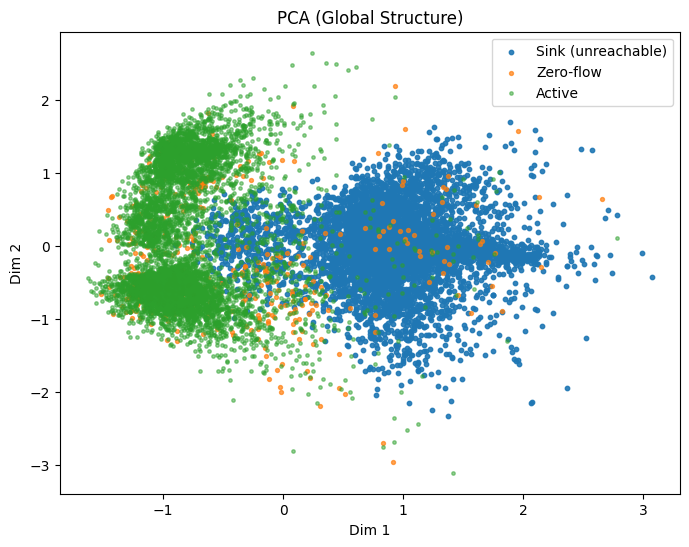

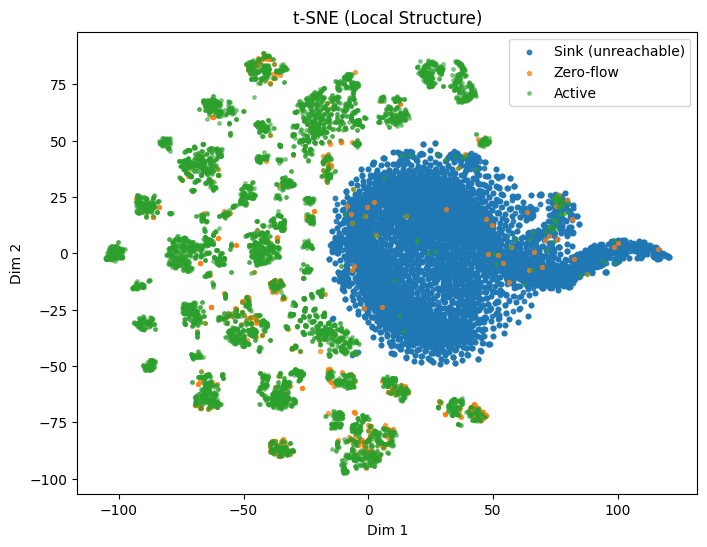

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


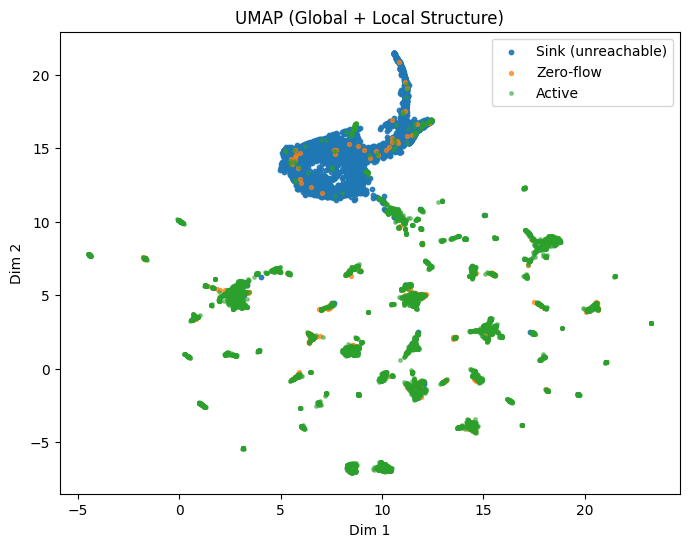

Visualization complete.


In [ ]:
# ============================================================
# INSTALL
# ============================================================
!pip install umap-learn --quiet

# ============================================================
# IMPORTS
# ============================================================
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# ============================================================
# PATHS (UPDATE IF NEEDED)
# ============================================================
GRAPH_PATH = "/content/reaction_graph_tpt_paper.pkl"
EMB_PATH   = "/content/molecule_embeddings_paper.pkl"

TARGET = r"[H]/N=C1\C=NCNC1=O"

# ============================================================
# LOAD GRAPH
# ============================================================
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

nodes = list(G.nodes())
print("Total nodes:", len(nodes))

# ============================================================
# TRUE UNREACHABLE (SINK NODES via reverse BFS)
# ============================================================
G_rev = G.reverse(copy=False)

productive_nodes = set(nx.bfs_tree(G_rev, TARGET).nodes())
productive_nodes.add(TARGET)

sink_nodes = set(nodes) - productive_nodes

print("Sink nodes (no path to target):", len(sink_nodes))

# ============================================================
# ZERO-FLOW NODES (no effective current outgoing)
# ============================================================
zero_flow_nodes = set()

for u in nodes:
    has_flow = False
    for _, v, data in G.out_edges(u, data=True):
        if data.get("effective_current", 0.0) > 0:
            has_flow = True
            break
    if not has_flow:
        zero_flow_nodes.add(u)

print("Zero-flow nodes:", len(zero_flow_nodes))

# ============================================================
# LOAD EMBEDDINGS
# ============================================================
with open(EMB_PATH, "rb") as f:
    emb_dict = pickle.load(f)

smiles_list = []
embeddings  = []

for n in nodes:
    if n in emb_dict:
        smiles_list.append(n)
        embeddings.append(emb_dict[n])

embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)

# ============================================================
# BUILD LABELS
# 0 = sink (RED)
# 1 = zero-flow (ORANGE)
# 2 = active (GREEN)
# ============================================================
labels = []

for s in smiles_list:
    if s in sink_nodes:
        labels.append(0)
    elif s in zero_flow_nodes:
        labels.append(1)
    else:
        labels.append(2)

labels = np.array(labels)

print("Label counts:", np.bincount(labels))

# ============================================================
# OPTIONAL SUBSAMPLING (for speed)
# ============================================================
MAX_POINTS = 15000

if len(embeddings) > MAX_POINTS:
    idx = np.random.choice(len(embeddings), MAX_POINTS, replace=False)
    embeddings = embeddings[idx]
    labels = labels[idx]

# ============================================================
# PLOT FUNCTION (CONSISTENT COLORS)
# ============================================================
def plot_embedding(X, title):
    plt.figure(figsize=(8,6))

    # RED → sinks
    plt.scatter(X[labels==0,0], X[labels==0,1],
                s=10, alpha=0.9, label="Sink (unreachable)")

    # ORANGE → zero-flow
    plt.scatter(X[labels==1,0], X[labels==1,1],
                s=8, alpha=0.7, label="Zero-flow")

    # GREEN → active
    plt.scatter(X[labels==2,0], X[labels==2,1],
                s=6, alpha=0.5, label="Active")

    plt.title(title)
    plt.legend()
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

# ============================================================
# PCA (GLOBAL STRUCTURE)
# ============================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(embeddings)

plot_embedding(X_pca, "PCA (Global Structure)")

# ============================================================
# t-SNE (LOCAL STRUCTURE)
# ============================================================
pca50 = PCA(n_components=50)
X50 = pca50.fit_transform(embeddings)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X50)

plot_embedding(X_tsne, "t-SNE (Local Structure)")

# ============================================================
# UMAP (GLOBAL + LOCAL)
# ============================================================
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(embeddings)

plot_embedding(X_umap, "UMAP (Global + Local Structure)")

# ============================================================
# DONE
# ============================================================
print("Visualization complete.")

In [ ]:
!pip install python-louvain gensim smart_open

In [ ]:
!pip uninstall community

##MULTI PAIR TPT WITH RANDOM WALK





In [ ]:
import pickle
import numpy as np
import networkx as nx
import random
import time
import os
from collections import defaultdict
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import bicgstab
from gensim.models import Word2Vec

# ============================================================
# GPU SETUP
# ============================================================

try:
    import cupy as cp
    import cupyx.scipy.sparse as csp
    import cupyx.scipy.sparse.linalg as cspla
    if cp.cuda.runtime.getDeviceCount() == 0:
        raise RuntimeError("No CUDA devices")
    GPU_AVAILABLE = True
    print(f"  [GPU] ENABLED — {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except Exception as e:
    GPU_AVAILABLE = False
    print(f"  [GPU] Not available ({e}) — CPU mode")

try:
    import community.community_louvain as community_louvain
    LOUVAIN_AVAILABLE = True
    print("  [Louvain] python-louvain available")
except ImportError:
    LOUVAIN_AVAILABLE = False
    print("  [Louvain] NOT available — using WCC fallback")

# ============================================================
# CONFIGURATION
# ============================================================

GRAPH_LOAD_PATH      = "reaction_graph_t_scaled.pkl"
GRAPH_SAVE_PATH      = "reaction_graph_tpt_paper3.pkl"
EMBEDDING_PKL_PATH   = "molecule_embeddings_paper3.pkl"
EMBEDDING_NPY_DIR    = "embeddings_individual_paper3"
EMBEDDING_INDEX_PATH = "embeddings_index_paper3.pkl"

# These are only used for Stage 5 similarity output — NOT as a hardcoded TPT pair
SOURCE_MOLECULE = r"C=NC(N)C(C)(C)C"
TARGET_MOLECULE = r"[H]/N=C1\C=NCNC1=O"

# Pair selection
MAX_PAIRS          = 20    # hard cap on pairs to run TPT for
MIN_CLUSTER_SIZE   = 20    # Louvain clusters smaller than this are merged/skipped
BFS_SAMPLE         = 50    # nodes scored per cluster when picking src/tgt
BFS_SCORE_LIMIT    = 500  # BFS node cap during scoring (speed vs accuracy)

# Walk / embedding
WALKS_PER_NODE = 10
WALK_LENGTH    = 9
WINDOW_SIZE    = 5
EMBEDDING_DIM  = 128
MIN_COUNT      = 1
NUM_WORKERS    = 4
SIM_HOPS       = 2

# ============================================================
# HELPERS
# ============================================================

def elapsed(start):
    s = time.time() - start
    return f"{s:.1f}s" if s < 60 else f"{s/60:.1f}min"

def progress(cur, total, start, prefix="  "):
    pct  = 100 * cur / total
    done = int(pct / 2)
    bar  = "#" * done + "-" * (50 - done)
    print(f"\r{prefix}[{bar}] {pct:5.1f}%  {elapsed(start)}", end="", flush=True)

# ============================================================
# LOAD
# ============================================================

print("=" * 60)
print("LOADING GRAPH")
print("=" * 60)
t0 = time.time()

with open(GRAPH_LOAD_PATH, "rb") as f:
    G = pickle.load(f)

nodes      = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}
N          = len(nodes)

print(f"  Nodes  : {N:,}")
print(f"  Edges  : {G.number_of_edges():,}")
print(f"  Loaded in {elapsed(t0)}")

assert SOURCE_MOLECULE in node_index, f"Source not found: {SOURCE_MOLECULE}"
assert TARGET_MOLECULE in node_index, f"Target not found: {TARGET_MOLECULE}"

# ============================================================
# PRECOMPUTE — COLLAPSE EDGES ONCE
# ============================================================

print("\n" + "=" * 60)
print("PRECOMPUTE — COLLAPSING EDGES (ONCE)")
print("=" * 60)
t_pre = time.time()

collapsed_w   = defaultdict(float)
collapsed_out = defaultdict(float)

for idx, (u, v, attrs) in enumerate(G.edges(data=True)):
    collapsed_w[(u, v)]  += attrs["weight"]
    collapsed_out[u]     += attrs["weight"]
    if (idx + 1) % 500_000 == 0:
        print(f"    edges scanned: {idx+1:,}")

print(f"  Unique (u,v) pairs : {len(collapsed_w):,}")

print("  Building transition matrix P (once)...")
P = lil_matrix((N, N), dtype=np.float64)
for (u, v), w in collapsed_w.items():
    out = collapsed_out[u]
    if out > 0:
        P[node_index[u], node_index[v]] = w / out
P_csr = P.tocsr()
del P

print("  Building edge index arrays (once)...")
edge_keys    = []
edge_u_arr   = []
edge_v_arr   = []
edge_wts_arr = []
for u, v, key, attrs in G.edges(keys=True, data=True):
    edge_keys.append((u, v, key))
    edge_u_arr.append(node_index[u])
    edge_v_arr.append(node_index[v])
    edge_wts_arr.append(attrs["weight"])
edge_u_arr   = np.array(edge_u_arr,   dtype=np.int32)
edge_v_arr   = np.array(edge_v_arr,   dtype=np.int32)
edge_wts_arr = np.array(edge_wts_arr, dtype=np.float64)

print("  Building adjacency dicts (once)...")
succ = {n: list(G.successors(n))   for n in nodes}
pred = {n: list(G.predecessors(n)) for n in nodes}

print(f"  Precompute done in {elapsed(t_pre)}")

# ============================================================
# STATIONARY DISTRIBUTION pi — ONCE
# ============================================================

print("\n" + "=" * 60)
print("COMPUTING STATIONARY DISTRIBUTION pi (ONCE)")
print("=" * 60)
t_pi = time.time()

def power_iter_cpu(P_csr, N, tol=1e-9, maxiter=1000):
    pi = np.ones(N) / N
    for it in range(maxiter):
        pi_new  = pi @ P_csr
        pi_new /= pi_new.sum()
        if np.max(np.abs(pi_new - pi)) < tol:
            print(f"  pi converged at iteration {it+1}  [CPU]")
            return pi_new
        pi = pi_new
    return pi

if GPU_AVAILABLE:
    try:
        P_gpu  = csp.csr_matrix(P_csr)
        pi_gpu = cp.ones(N, dtype=cp.float64) / N
        for it in range(1000):
            pi_new = pi_gpu @ P_gpu
            pi_new /= pi_new.sum()
            if float(cp.max(cp.abs(pi_new - pi_gpu))) < 1e-9:
                print(f"  pi converged at iteration {it+1}  [GPU]")
                break
            pi_gpu = pi_new
        pi = cp.asnumpy(pi_gpu)
        del P_gpu, pi_gpu, pi_new
        cp.get_default_memory_pool().free_all_blocks()
    except Exception as e:
        print(f"  GPU power iter failed ({e}), using CPU")
        pi = power_iter_cpu(P_csr, N)
else:
    pi = power_iter_cpu(P_csr, N)

for n, i in node_index.items():
    G.nodes[n]["pi"] = float(pi[i])

print(f"  pi sum : {pi.sum():.8f}")
print(f"  pi done in {elapsed(t_pi)}")

# ============================================================
# BFS UTILITIES
# ============================================================

def bfs_fwd_count(start, limit=BFS_SCORE_LIMIT):
    vis = {start}; q = [start]
    while q and len(vis) < limit:
        nxt = []
        for u in q:
            for v in succ[u]:
                if v not in vis: vis.add(v); nxt.append(v)
        q = nxt
    return len(vis)

def bfs_bwd_count(start, limit=BFS_SCORE_LIMIT):
    vis = {start}; q = [start]
    while q and len(vis) < limit:
        nxt = []
        for u in q:
            for v in pred[u]:
                if v not in vis: vis.add(v); nxt.append(v)
        q = nxt
    return len(vis)

def bfs_descendants(start, limit=None):
    vis = set(); q = [start]
    while q:
        if limit and len(vis) >= limit: break
        nxt = []
        for u in q:
            for v in succ[u]:
                if v not in vis: vis.add(v); nxt.append(v)
        q = nxt
    return vis

def bfs_ancestors(start, limit=None):
    vis = set(); q = [start]
    while q:
        if limit and len(vis) >= limit: break
        nxt = []
        for u in q:
            for v in pred[u]:
                if v not in vis: vis.add(v); nxt.append(v)
        q = nxt
    return vis

def can_reach(src, tgt, limit=7000):
    if src == tgt: return False
    vis = {src}; q = [src]
    while q and len(vis) < limit:
        nxt = []
        for u in q:
            for v in succ[u]:
                if v == tgt: return True
                if v not in vis: vis.add(v); nxt.append(v)
        q = nxt
    return False

# ============================================================
# STEP 1 — CLUSTER ENTIRE GRAPH (UNDIRECTED PROJECTION)
# ============================================================
# We cluster all 123k nodes at once on the undirected weighted
# projection. Louvain naturally finds communities regardless of
# whether nodes are productive or sink — that distinction only
# matters when we solve the linear system, not for clustering.
#
# The productive/sink split is NOT used for clustering because:
#   - Sink nodes form thousands of tiny WCCs (< 100 nodes each)
#     and would all be dropped if we cluster them separately.
#   - Louvain on the full undirected graph groups nodes by
#     reaction similarity, which is exactly what we want for
#     picking representative source-target pairs.
#   - A cluster may span productive and sink nodes — we will
#     then pick a (src, tgt) pair that is connected, and the
#     solver will handle the boundary conditions correctly.

print("\n" + "=" * 60)
print("STEP 1 — CLUSTERING FULL GRAPH (UNDIRECTED)")
print("=" * 60)
t_clust = time.time()

if LOUVAIN_AVAILABLE:
    print("  Building undirected weighted projection...")
    G_und = nx.Graph()
    G_und.add_nodes_from(nodes)
    for (u, v), w in collapsed_w.items():
        if G_und.has_edge(u, v):
            G_und[u][v]["weight"] += w
        else:
            G_und.add_edge(u, v, weight=w)

    print("  Running Louvain...")
    partition = community_louvain.best_partition(
        G_und, weight="weight", random_state=42)
    del G_und

    raw_clusters = defaultdict(list)
    for node, cid in partition.items():
        raw_clusters[cid].append(node)

    # Keep clusters >= MIN_CLUSTER_SIZE; collect remainder
    clusters   = {}
    small_pool = []
    for cid, members in raw_clusters.items():
        if len(members) >= MIN_CLUSTER_SIZE:
            clusters[len(clusters)] = members
        else:
            small_pool.extend(members)

    # Re-assign small-pool nodes to nearest large cluster by shared edges
    if small_pool:
      print(f"  Re-assigning {len(small_pool):,} nodes from small clusters...")
      node2cid = {}
      for cid, members in clusters.items():
          for m in members:
              node2cid[m] = cid

      # Group isolated small-pool nodes into synthetic clusters of size 20
      unconnected = []
      for n in small_pool:
          votes = defaultdict(float)
          for v in succ[n]:
              if v in node2cid:
                  votes[node2cid[v]] += collapsed_w.get((n, v), 0)
          for v in pred[n]:
              if v in node2cid:
                  votes[node2cid[v]] += collapsed_w.get((v, n), 0)
          if votes:
              best_cid = max(votes, key=votes.get)
              clusters[best_cid].append(n)
              node2cid[n] = best_cid
          else:
              unconnected.append(n)

      # Bundle truly isolated nodes into synthetic clusters of 20
      SYNTHETIC_SIZE = 20
      for i in range(0, len(unconnected), SYNTHETIC_SIZE):
          chunk = unconnected[i:i + SYNTHETIC_SIZE]
          new_cid = max(clusters.keys()) + 1
          clusters[new_cid] = chunk
          for m in chunk:
              node2cid[m] = new_cid
      if unconnected:
          print(f"  Bundled {len(unconnected):,} isolated nodes into "
                f"{len(unconnected)//SYNTHETIC_SIZE + 1} synthetic clusters")

    sizes = sorted([len(v) for v in clusters.values()], reverse=True)
    print(f"  Louvain clusters (>= {MIN_CLUSTER_SIZE}) : {len(clusters)}")
    print(f"  Largest : {sizes[0]:,}  |  Median : {sizes[len(sizes)//2]:,}  |  Smallest : {sizes[-1]:,}")
    total_clustered = sum(len(v) for v in clusters.values())
    print(f"  Nodes assigned to clusters : {total_clustered:,} / {N:,} "
          f"({100*total_clustered/N:.1f}%)")

else:
    # Fallback: use weakly connected components of full graph
    print("  Louvain not available — using WCCs of full graph...")
    clusters = {}
    for wcc in nx.weakly_connected_components(G):
        if len(wcc) >= MIN_CLUSTER_SIZE:
            clusters[len(clusters)] = list(wcc)
    print(f"  WCC clusters >= {MIN_CLUSTER_SIZE} : {len(clusters)}")

print(f"  Clustering done in {elapsed(t_clust)}")

# ============================================================
# STEP 2 — EXTRACT ONE VALID (src, tgt) PAIR PER CLUSTER
# ============================================================
# For each cluster:
#   Score BFS_SAMPLE random members for forward reach (src candidate)
#   and backward reach (tgt candidate).
#   Try top-K × top-K combinations, skip same node, verify can_reach().
#   Fallback 1: scan edges within cluster.
#   Fallback 2: skip cluster (no directed edges internally).

print("\n" + "=" * 60)
print("STEP 2 — EXTRACT CANDIDATE PAIR PER CLUSTER")
print("=" * 60)
t_extract = time.time()

all_candidate_pairs   = []
failed                = 0
seen_bwd_sizes_global = []
total_clusters        = len(clusters)
t_step2               = time.time()

# Hard cap on bwd basin size for pair acceptance
BWD_LIMIT   = int(0.15 * N)   # reject if basin > 15% of graph
BWD_SCAN    = 2000             # limit bfs_ancestors scan in Step 2

for cid_num, (cid, members) in enumerate(clusters.items()):

    if cid_num % 200 == 0:
        print(f"  [{cid_num:>4}/{total_clusters}] pairs: {len(all_candidate_pairs):>5}  "
              f"failed: {failed:>4}  elapsed: {elapsed(t_step2)}")

    member_set = set(members)
    found      = False

    # ---- PATH 1: internal directed edge scan (ALL cluster sizes) ----
    # Fast O(edges-in-cluster), no BFS needed
    best_pair  = None
    best_depth = 0
    for n in members:
        for v in succ[n]:
            if v not in member_set or v == n:
                continue
            depth = sum(1 for p in pred[v] if p in member_set)
            if depth > best_depth:
                best_pair  = (n, v)
                best_depth = depth

    if best_pair:
        s, t   = best_pair
        bwd    = bfs_ancestors(t, limit=BWD_SCAN)
        bwd_sz = len(bwd)
        # Only apply basin filter for large clusters — synthetic clusters
        # will naturally have small basins anyway
        if bwd_sz <= BWD_LIMIT:
            if not any(abs(bwd_sz - prev) < 0.05 * N
                       for prev in seen_bwd_sizes_global):
                seen_bwd_sizes_global.append(bwd_sz)
            all_candidate_pairs.append((s, t, cid))
            found = True

    # ---- PATH 2: large cluster BFS scoring (only if internal edge failed) ----
    if not found and len(members) >= 25:
        sample  = random.sample(members, min(BFS_SAMPLE, len(members)))
        scored  = [(n, bfs_fwd_count(n), bfs_bwd_count(n)) for n in sample]
        top_src = [x[0] for x in sorted(scored, key=lambda x: x[1], reverse=True)[:8]]
        top_tgt = [x[0] for x in sorted(scored, key=lambda x: x[2], reverse=True)[:8]]

        for s in top_src:
            for t in top_tgt:
                if s == t:
                    continue
                if not can_reach(s, t):
                    continue
                bwd    = bfs_ancestors(t, limit=BWD_SCAN)
                bwd_sz = len(bwd)
                if bwd_sz > BWD_LIMIT:
                    continue
                if any(abs(bwd_sz - prev) < 0.05 * N
                       for prev in seen_bwd_sizes_global):
                    continue
                seen_bwd_sizes_global.append(bwd_sz)
                all_candidate_pairs.append((s, t, cid))
                found = True
                break
            if found:
                break

    # ---- PATH 3: cross-cluster edge, capped bwd check ----
    if not found:
        for n in members:
            for v in succ[n]:
                if v == n or v not in node_index:
                    continue
                bwd    = bfs_ancestors(v, limit=BWD_SCAN)
                bwd_sz = len(bwd)
                if bwd_sz <= BWD_LIMIT:
                    all_candidate_pairs.append((n, v, cid))
                    found = True
                    break
            if found:
                break

    if not found:
        failed += 1

print(f"\n  [{total_clusters}/{total_clusters}] pairs: {len(all_candidate_pairs):>5}  "
      f"failed: {failed:>4}  elapsed: {elapsed(t_step2)}")
print(f"\n  Backward sizes of selected pairs (first 10, capped at {BWD_SCAN}):")
for s, t, cid in all_candidate_pairs[:10]:
    print(f"    bwd={len(bfs_ancestors(t, limit=BWD_SCAN)):,}  "
          f"src={s[:40]!r}  tgt={t[:40]!r}")
print(f"  Candidate pairs extracted : {len(all_candidate_pairs):,} / {len(clusters):,} clusters")
if failed:
    print(f"  Clusters with no valid pair : {failed}  (no edges at all)")
print(f"  Pair extraction done in {elapsed(t_extract)}")

# ============================================================
# STEP 3 — GREEDY COVERAGE SELECTION
# ============================================================
# Pick up to MAX_PAIRS pairs that maximise the number of nodes
# covered by at least one TPT flow (fwd_descendants ∩ bwd_ancestors).
# All pairs come from clustering — no hardcoded pair.

print("\n" + "=" * 60)
print("STEP 3 — GREEDY COVERAGE SELECTION")
print("=" * 60)
t_greedy = time.time()

selected_pairs = []
covered_nodes  = set()
remaining      = list(all_candidate_pairs)   # (src, tgt, cid)

for step in range(MAX_PAIRS):
    if not remaining:
        break
    if len(covered_nodes) / N >= 0.95:
        print(f"  95% coverage reached at pair #{len(selected_pairs)}")
        break

    best_gain = -1
    best_pair = None
    best_new  = None
    best_idx  = -1

    bwd_cache = {}

    for i, (s, t, cid) in enumerate(remaining):
        fwd = bfs_descendants(s)
        if t not in bwd_cache:
            bwd_cache[t] = bfs_ancestors(t)
        bwd = bwd_cache[t]
        new = (fwd & bwd) - covered_nodes
        # Also count src and tgt themselves
        new.discard(s); new.discard(t)
        gain = len(new) + (1 if s not in covered_nodes else 0) \
                        + (1 if t not in covered_nodes else 0)
        if gain > best_gain:
            best_gain = gain
            best_pair = (s, t)
            best_new  = new | {s, t}
            best_idx  = i

    if best_pair is None or best_gain == 0:
        # All remaining pairs add 0 new nodes.
        # Add one-per-cluster anyway so every cluster contributes to f+.
        seen_cids = set(c for _, _, c in [(*p, -1) for p in selected_pairs])
        # rebuild seen_cids properly
        selected_cids = set()
        for s, t, cid in all_candidate_pairs:
            if (s, t) in [(sp[0], sp[1]) for sp in selected_pairs]:
                selected_cids.add(cid)
        added = 0
        for s, t, cid in remaining:
            if cid not in selected_cids and len(selected_pairs) < MAX_PAIRS:
                selected_pairs.append((s, t))
                selected_cids.add(cid)
                added += 1
        print(f"  No more coverage gain — added {added} remaining cluster pairs")
        break

    selected_pairs.append(best_pair)
    covered_nodes.update(best_new)
    remaining.pop(best_idx)

    print(f"  Pair {len(selected_pairs):>3}: +{best_gain:>6,} new  "
          f"covered={len(covered_nodes):,}/{N:,}  "
          f"({100*len(covered_nodes)/N:.1f}%)")

print(f"\n  Selected pairs   : {len(selected_pairs)}")
print(f"  Node coverage    : {len(covered_nodes):,} / {N:,} "
      f"({100*len(covered_nodes)/N:.1f}%)")
print(f"  Uncovered        : {N-len(covered_nodes):,}  "
      f"(nodes with no directed path to any selected target)")
print(f"  Greedy done in {elapsed(t_greedy)}")

# Print selected pairs
print(f"\n  All selected pairs:")
for i, (s, t) in enumerate(selected_pairs):
    print(f"    {i+1:>3}: {s[:45]!r:47} -> {t[:45]!r}")

print(f"\n  Diagnostic — backward/forward basin sizes:")
for i, (s, t) in enumerate(selected_pairs):
    bwd_size = len(bfs_ancestors(t))
    fwd_size = len(bfs_descendants(s))
    print(f"    Pair {i+1:>3}: bwd={bwd_size:>7,} ({100*bwd_size/N:.1f}%)  "
          f"fwd={fwd_size:>7,} ({100*fwd_size/N:.1f}%)")

# ============================================================
# STAGE 1+2 LOOP — q+ AND f+ PER PAIR, ACCUMULATED
# ============================================================

print("\n" + "=" * 60)
print(f"STAGES 1+2 — q+ AND f+  ({len(selected_pairs)} PAIRS)")
print("=" * 60)
t_stage12 = time.time()

f_total  = np.zeros(len(edge_keys), dtype=np.float64)
q_sum    = np.zeros(N,              dtype=np.float64)
q_counts = np.zeros(N,              dtype=np.int32)

for pair_idx, (src_mol, tgt_mol) in enumerate(selected_pairs):
    t_pair    = time.time()
    src_idx_p = node_index[src_mol]
    tgt_idx_p = node_index[tgt_mol]

    print(f"\n  --- Pair {pair_idx+1}/{len(selected_pairs)} ---")
    print(f"  Source : {src_mol[:70]}")
    print(f"  Target : {tgt_mol[:70]}")

    # Per-pair sink pruning — reverse BFS from THIS target
    G_rev_p      = G.reverse(copy=False)
    productive_p = set(nx.bfs_tree(G_rev_p, tgt_mol).nodes())
    productive_p.add(tgt_mol)
    sink_nodes_p = set(nodes) - productive_p
    print(f"  Productive : {len(productive_p):,}  |  Sinks : {len(sink_nodes_p):,}")

    boundary_p = {src_idx_p, tgt_idx_p}

    # Assemble Laplacian L for this pair
    L = lil_matrix((N, N), dtype=np.float64)
    for (u, v), w in collapsed_w.items():
        i, j = node_index[u], node_index[v]
        if i in boundary_p:
            continue
        L[i, j] += w
        L[i, i] -= w
    for idx_b in boundary_p:
        L[idx_b, idx_b] = 1.0

    L_csr_p = L.tocsr()
    del L

    rhs            = np.zeros(N)
    rhs[tgt_idx_p] = 1.0

    # Solve q+
    if GPU_AVAILABLE:
        t_s     = time.time()
        L_gpu   = csp.csr_matrix(L_csr_p)
        rhs_gpu = cp.array(rhs)
        q_gpu, info = cspla.gmres(L_gpu, rhs_gpu, restart=50, maxiter=1000)
        if info != 0:
            print(f"  WARNING: GMRES info={info} (not fully converged)")
        q_plus_p = cp.asnumpy(q_gpu)
        del L_gpu, rhs_gpu, q_gpu
        cp.get_default_memory_pool().free_all_blocks()
        print(f"  q+ solved [GPU] in {elapsed(t_s)}")
    else:
        t_s      = time.time()
        q_plus_p, info = bicgstab(L_csr_p, rhs, tol=1e-6, maxiter=1000)
        if info != 0:
            print(f"  WARNING: BiCGSTAB info={info}")
        print(f"  q+ solved [CPU] in {elapsed(t_s)}")

    del L_csr_p
    q_plus_p = np.clip(q_plus_p, 0.0, 1.0)

    # Accumulate q+ over productive nodes of this pair
    prod_idx = np.array([node_index[n] for n in productive_p], dtype=np.int32)
    q_sum[prod_idx]    += q_plus_p[prod_idx]
    q_counts[prod_idx] += 1

    nz_q = int(np.sum(q_plus_p > 1e-10))
    print(f"  q+ min/max : {q_plus_p.min():.6f} / {q_plus_p.max():.6f}")
    print(f"  q+ > 0 : {nz_q:,}  |  mean (productive) : "
          f"{q_plus_p[prod_idx].mean():.6f}")

    # Compute f+ (vectorised), normalise, accumulate
    f_plus_p   = np.maximum(
        edge_wts_arr * (q_plus_p[edge_v_arr] - q_plus_p[edge_u_arr]), 0.0)
    total_flow = f_plus_p.sum()
    if total_flow > 0:
        f_plus_p /= total_flow
    f_total += f_plus_p

    print(f"  f+ active : {int(np.sum(f_plus_p>0)):,}  |  pair time : {elapsed(t_pair)}")

print(f"\n  All {len(selected_pairs)} pairs done  [{elapsed(t_stage12)}]")

# Write to graph
print("  Writing aggregated f+ to edges...")
for i, (u, v, key) in enumerate(edge_keys):
    G[u][v][key]["effective_current"] = float(f_total[i])

print("  Writing averaged q+ to nodes...")
with np.errstate(divide="ignore", invalid="ignore"):
    q_avg = np.where(q_counts > 0, q_sum / q_counts, 0.0)
for n, i in node_index.items():
    G.nodes[n]["q_plus"] = float(q_avg[i])

n_edges   = len(edge_keys)
zeroed    = int(np.sum(f_total == 0.0))
q_nonzero = int(np.sum(q_avg > 1e-10))
print(f"\n  f+ = 0 (inactive) : {zeroed:,} / {n_edges:,}  ({100*zeroed/n_edges:.1f}%)")
print(f"  f+ > 0 (active)   : {n_edges-zeroed:,}  ({100*(n_edges-zeroed)/n_edges:.1f}%)")
print(f"  q+ > 0 nodes      : {q_nonzero:,} / {N:,}  ({100*q_nonzero/N:.1f}%)")

del q_sum, q_counts, q_avg, f_plus_p, f_total

# ============================================================
# STAGE 3 — BIASED RANDOM WALKS
# ============================================================

print("\n" + "=" * 60)
print("STAGE 3 — BIASED RANDOM WALKS FROM EVERY NODE")
print("=" * 60)
t3 = time.time()

print(f"  Nodes : {N:,}  |  Walks/node : {WALKS_PER_NODE}  |  "
      f"Length : {WALK_LENGTH}  |  Total : {WALKS_PER_NODE*N:,}")

print("  Pre-building adjacency cache (aggregated f+)...")
t_adj = time.time()
adj   = {}
for i, u in enumerate(nodes):
    cands, f_wts, raw_wts = [], [], []
    for _, v, key, attrs in G.out_edges(u, keys=True, data=True):
        cands.append(v)
        f_wts.append(attrs["effective_current"])
        raw_wts.append(attrs["weight"])
    adj[u] = (cands, f_wts, raw_wts)
    if (i + 1) % 20_000 == 0:
        progress(i + 1, N, t_adj, prefix="    ")
print(f"\r  Adjacency cache done in {elapsed(t_adj)}              ")

def sample_next(u):
    cands, f_wts, raw_wts = adj[u]
    if not cands: return None
    total_f = sum(f_wts)
    weights = f_wts if total_f > 0 else raw_wts
    total_w = total_f if total_f > 0 else sum(raw_wts)
    if total_w == 0: return None
    r, cumul = random.uniform(0, total_w), 0.0
    for v, w in zip(cands, weights):
        cumul += w
        if r <= cumul: return v
    return cands[-1]

print("  Running walks...")
t_walk = time.time()
walks       = []
co_occ      = defaultdict(lambda: defaultdict(int))
visit_count = defaultdict(int)

for node_idx, start in enumerate(nodes):
    for _ in range(WALKS_PER_NODE):
        walk = [start]; cur = start
        for _ in range(WALK_LENGTH):
            nxt = sample_next(cur)
            if nxt is None: break
            walk.append(nxt); cur = nxt
        walks.append(walk)
        for wi, mol_i in enumerate(walk):
            visit_count[mol_i] += 1
            for mol_j in walk[max(0, wi-WINDOW_SIZE):wi]:
                co_occ[mol_i][mol_j] += 1
                co_occ[mol_j][mol_i] += 1
    if (node_idx + 1) % 5_000 == 0:
        progress(node_idx + 1, N, t_walk)

print(f"\r  Walks complete.                                      ")

avg_len   = sum(len(w) for w in walks) / len(walks)
n_seen    = len(visit_count)
n_reached = sum(1 for w in walks if TARGET_MOLECULE in w)
print(f"  Avg length : {avg_len:.2f}  |  "
      f"Unique nodes seen : {n_seen:,}/{N:,} ({100*n_seen/N:.1f}%)")
print(f"  Walks reaching reference target : {n_reached:,}")
print(f"  Stage 3 done in {elapsed(t3)}")

del co_occ, visit_count, adj

# ============================================================
# STAGE 4 — SKIP-GRAM EMBEDDING
# ============================================================

print("\n" + "=" * 60)
print("STAGE 4 — SKIP-GRAM EMBEDDING")
print("=" * 60)
t4 = time.time()

print(f"  dim={EMBEDDING_DIM}  window={WINDOW_SIZE}  epochs=20  workers={NUM_WORKERS}")
print("  Training Word2Vec...")

model = Word2Vec(
    sentences=walks, vector_size=EMBEDDING_DIM, window=WINDOW_SIZE,
    min_count=MIN_COUNT, sg=1, workers=NUM_WORKERS, epochs=20)
del walks

embedding_dict = {}
unembedded     = []
for n in nodes:
    if n in model.wv:
        vec = model.wv[n].copy()
        G.nodes[n]["embedding"] = vec.tolist()
        embedding_dict[n]       = vec
    else:
        G.nodes[n]["embedding"] = None
        unembedded.append(n)

embedded = len(embedding_dict)
print(f"  Embedded   : {embedded:,} / {N:,} ({100*embedded/N:.1f}%)")
if unembedded:
    print(f"  Unembedded : {len(unembedded):,}  (no edges at all)")

print(f"  Saving bulk embeddings -> {EMBEDDING_PKL_PATH}")
with open(EMBEDDING_PKL_PATH, "wb") as f:
    pickle.dump(embedding_dict, f)

print(f"  Saving .npy files -> {EMBEDDING_NPY_DIR}/")
os.makedirs(EMBEDDING_NPY_DIR, exist_ok=True)
index_map = {}
t_npy     = time.time()
for i, (smiles, vec) in enumerate(embedding_dict.items()):
    fname = f"mol_{i:07d}.npy"
    np.save(os.path.join(EMBEDDING_NPY_DIR, fname), vec)
    index_map[smiles] = fname
    if (i + 1) % 10_000 == 0:
        progress(i + 1, len(embedding_dict), t_npy, prefix="    ")
print(f"\r  {len(embedding_dict):,} .npy files saved in {elapsed(t_npy)}              ")

print(f"  Saving index -> {EMBEDDING_INDEX_PATH}")
with open(EMBEDDING_INDEX_PATH, "wb") as f:
    pickle.dump(index_map, f)
print(f"  Stage 4 done in {elapsed(t4)}")

# ============================================================
# STAGE 5 — SIMILARITY PROPAGATION FROM REFERENCE SOURCE
# ============================================================

print("\n" + "=" * 60)
print("STAGE 5 — SIMILARITY PROPAGATION FROM REFERENCE SOURCE")
print("=" * 60)
t5 = time.time()

src_vec = embedding_dict.get(SOURCE_MOLECULE)
if src_vec is None:
    print("  WARNING: reference source has no embedding. Skipping.")
else:
    E     = np.zeros((N, EMBEDDING_DIM), dtype=np.float64)
    valid = np.zeros(N, dtype=bool)
    for n, vec in embedding_dict.items():
        i = node_index[n]; E[i] = vec; valid[i] = True

    norms = np.linalg.norm(E, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    E_norm = E / norms

    print("  Hop 0: batch cosine similarity to reference source...")
    src_unit = E_norm[node_index[SOURCE_MOLECULE]]
    sim_arr  = np.where(valid, E_norm @ src_unit, 0.0)

    print("  Building active-edge arrays...")
    act_u, act_v = [], []
    for u, v, attrs in G.edges(data=True):
        if attrs["effective_current"] > 0:
            act_u.append(node_index[u])
            act_v.append(node_index[v])
    act_u  = np.array(act_u, dtype=np.int32)
    act_v  = np.array(act_v, dtype=np.int32)
    cos_uv = np.einsum("ij,ij->i", E_norm[act_u], E_norm[act_v])

    for hop in range(SIM_HOPS):
        t_hop   = time.time()
        sim_new = sim_arr.copy()
        np.maximum.at(sim_new, act_v, sim_arr[act_u] * cos_uv)
        sim_arr = sim_new
        print(f"  Hop {hop+1}/{SIM_HOPS} done in {elapsed(t_hop)}")

    for n in nodes:
        G.nodes[n]["similarity_to_source"] = float(sim_arr[node_index[n]])

    sim_dict  = {n: float(sim_arr[node_index[n]]) for n in nodes}
    src_succs = set(G.successors(SOURCE_MOLECULE))
    candidates = sorted(
        [(n, sim_dict[n]) for n in nodes
         if n not in {SOURCE_MOLECULE, TARGET_MOLECULE}
         and n not in src_succs and n in embedding_dict],
        key=lambda x: x[1], reverse=True)

    print(f"\n  Top 10 candidates relative to reference source:")
    print(f"  {'Molecule':<50} {'similarity':>10}")
    print(f"  {'-'*50} {'-'*10}")
    for mol, s in candidates[:10]:
        print(f"  {mol[:50]:<50} {s:>10.6f}")

print(f"  Stage 5 done in {elapsed(t5)}")

# ============================================================
# SAVE
# ============================================================

print("\n" + "=" * 60)
print("SAVING ENRICHED GRAPH")
print("=" * 60)
t_save = time.time()
with open(GRAPH_SAVE_PATH, "wb") as f:
    pickle.dump(G, f)
print(f"  Saved in {elapsed(t_save)}")

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  {GRAPH_SAVE_PATH:<45} enriched graph")
print(f"  {EMBEDDING_PKL_PATH:<45} embeddings dict")
print(f"  {EMBEDDING_INDEX_PATH:<45} smiles->filename index")
print(f"  {EMBEDDING_NPY_DIR+'/':<45} individual .npy files")
print("\nNode attributes:")
print("  q_plus               — averaged committor (multi-pair TPT)")
print("  pi                   — stationary probability")
print("  embedding            — 128-d float list or None")
print("  similarity_to_source — cosine sim propagated from ref source")
print("\nEdge attributes:")
print("  effective_current    — normalized aggregated f+")
print(f"\nPairs used      : {len(selected_pairs)}")
print(f"Node coverage   : {len(covered_nodes):,} / {N:,} ({100*len(covered_nodes)/N:.1f}%)")
print(f"Total time      : {elapsed(t0)}")
print("DONE.")

  [GPU] ENABLED — Tesla T4
  [Louvain] python-louvain available
LOADING GRAPH
  Nodes  : 123,174
  Edges  : 770,844
  Loaded in 21.1s

PRECOMPUTE — COLLAPSING EDGES (ONCE)
    edges scanned: 500,000
  Unique (u,v) pairs : 413,822
  Building transition matrix P (once)...
  Building edge index arrays (once)...
  Building adjacency dicts (once)...
  Precompute done in 11.7s

COMPUTING STATIONARY DISTRIBUTION pi (ONCE)
  pi sum : 1.00000000
  pi done in 0.4s

STEP 1 — CLUSTERING FULL GRAPH (UNDIRECTED)
  Building undirected weighted projection...
  Running Louvain...
  Re-assigning 60,236 nodes from small clusters...
  Bundled 57,420 isolated nodes into 2872 synthetic clusters
  Louvain clusters (>= 20) : 2938
  Largest : 6,883  |  Median : 20  |  Smallest : 20
  Nodes assigned to clusters : 123,174 / 123,174 (100.0%)
  Clustering done in 15.8s

STEP 2 — EXTRACT CANDIDATE PAIR PER CLUSTER
  [   0/2938] pairs:     0  failed:    0  elapsed: 0.0s
  [ 200/2938] pairs:   200  failed:    0  elap

Loading graph ...
  Nodes : 123,174  |  Edges : 770,844

Node coverage breakdown:
  True sinks (q+=0, unreachable by any pair) :  56,624  (46.0%)
  Reached / passive (q+>0, f+=0)             :     325  (0.3%)
  Active (q+>0, f+>0)                        :  66,225  (53.8%)
  Total coverage (reached+active)             :  66,550  (54.0%)

Loading embeddings ...
  Embedded molecules : 123,174 / 123,174
  Embedding dim      : 128

Subsampling to 15,000 points (stratified) ...
  Points for projection : 15,284

Running PCA ...
  PCA variance explained: PC1=0.136  PC2=0.027  sum=0.163
Running t-SNE (PCA-50 init) ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running UMAP ...

Computing embedding quality metrics ...
  Mean intra-category cosine similarity : 0.4717
  Mean inter-category cosine similarity : 0.3775
  Separation (intra - inter)            : 0.0942  (good)

  Embedding norm correlations:
    with q_plus (committor)       : -0.4010
    with pi (stationary dist)     : +0.0983
    with outgoing eff. current    : +0.0106


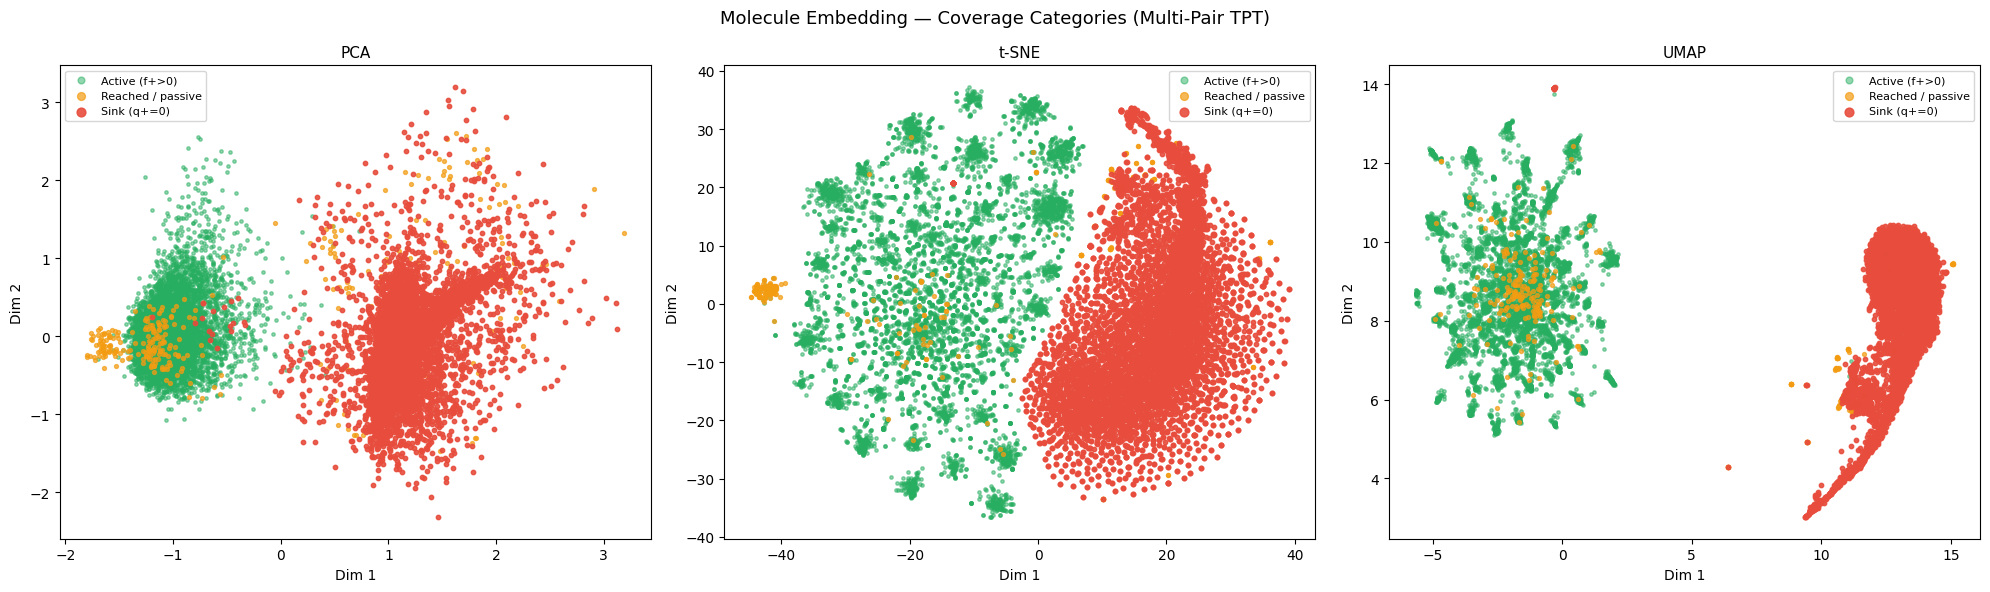

Saved: viz_coverage_categories.png


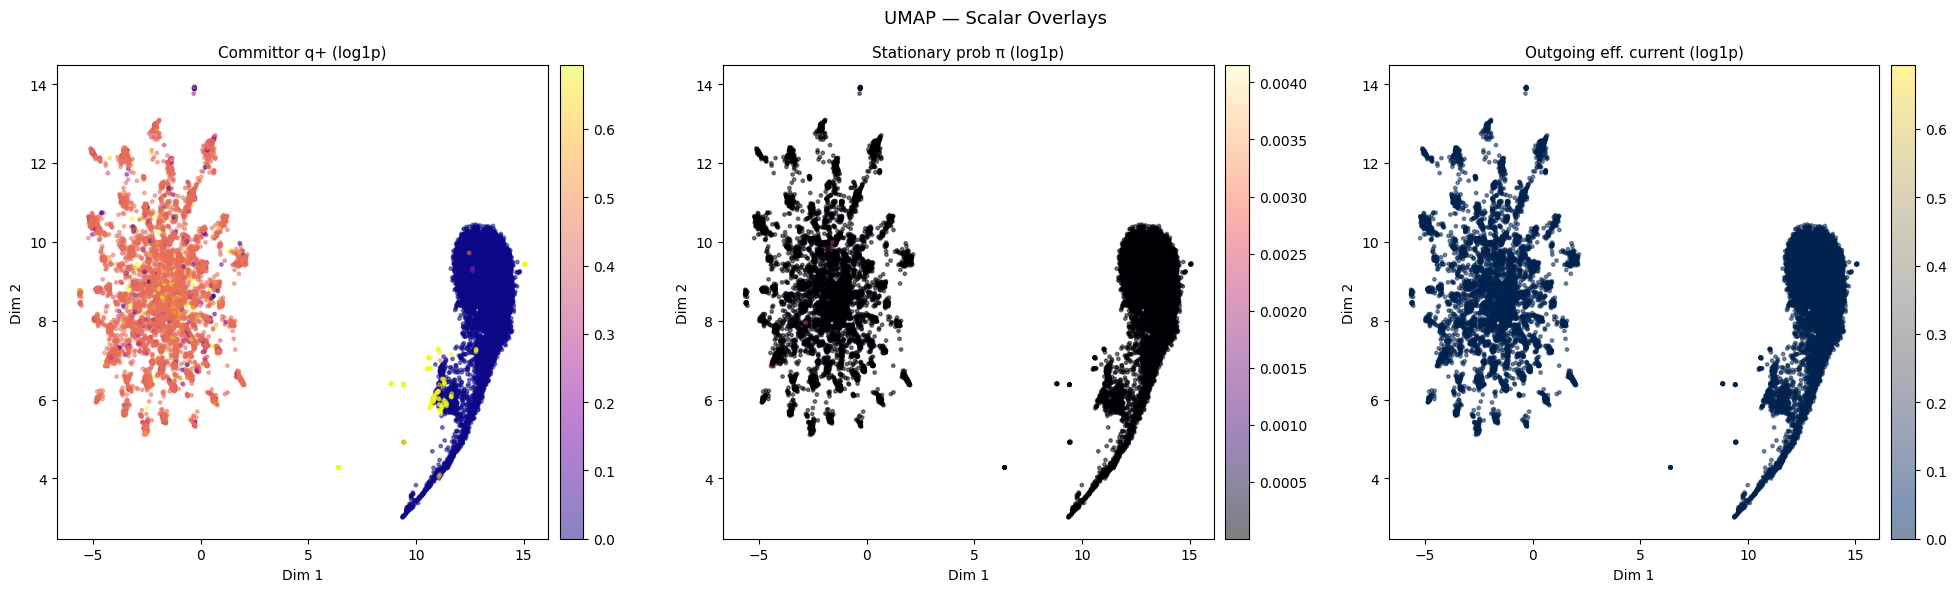

Saved: viz_scalar_overlays.png


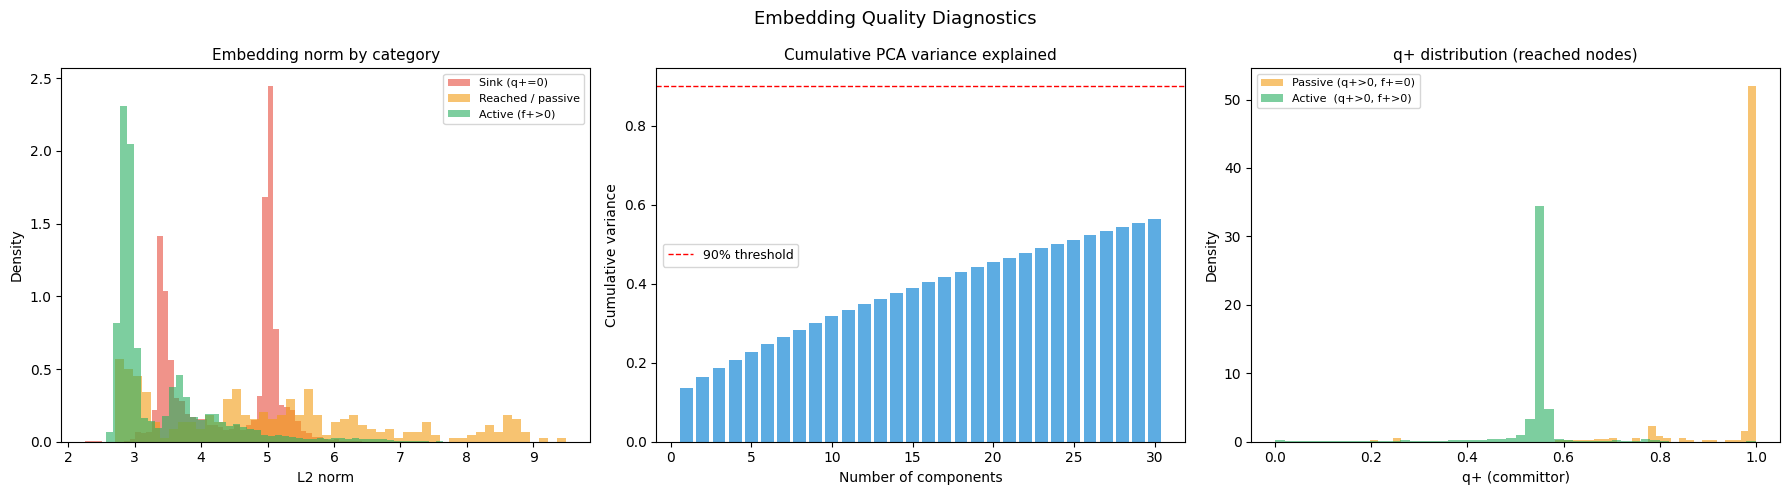

Saved: viz_quality_diagnostics.png

VISUALIZATION SUMMARY
  Graph nodes              : 123,174
  Embedded molecules       : 15,284
  True sinks (q+=0)        : 56,624  (46.0%)
  Reached / passive        : 325  (0.3%)
  Active (f+>0)            : 66,225  (53.8%)
  Multi-pair coverage      : 54.0%

  PCA var (PC1+PC2)        : 0.163
  Intra/inter sep          : +0.0942
  Norm ~ q+ corr           : -0.4010
  Norm ~ π corr            : +0.0983
  Norm ~ eff.current corr  : +0.0106
Done.


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import umap

# ============================================================
# PATHS
# ============================================================
GRAPH_PATH   = "reaction_graph_tpt_paper3.pkl"
EMB_PATH     = "molecule_embeddings_paper3.pkl"
#CLUSTER_PATH = "mol_cluster_artifacts.pkl"   # optional — loaded if present

# ============================================================
# LOAD GRAPH
# ============================================================
print("Loading graph ...")
with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

nodes      = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}
N          = len(nodes)
print(f"  Nodes : {N:,}  |  Edges : {G.number_of_edges():,}")

# ============================================================
# COVERAGE CATEGORIES (MULTI-PAIR AWARE)
# ============================================================
# CHANGE: Single-target reverse BFS replaced by graph-attribute-based
# classification. The updated TPT script writes q_plus (averaged committor
# over all pairs) and effective_current (aggregated f+) to every node/edge.
# A node is "reached" if q_plus > 0, i.e. it sits on a path that matters
# to at least one selected (src, tgt) pair. This is strictly more
# informative than a single reverse-BFS from one hardcoded target.

q_plus_arr  = np.array([G.nodes[n].get("q_plus",           0.0) for n in nodes])
pi_arr      = np.array([G.nodes[n].get("pi",                0.0) for n in nodes])

# Per-node total outgoing effective current
out_current = np.zeros(N)
for u, v, data in G.edges(data=True):
    out_current[node_index[u]] += data.get("effective_current", 0.0)

# Category thresholds (tune if needed)
Q_THRESH   = 1e-12    # minimum q+ to count as "reached"
F_THRESH   = 1e-10   # minimum outgoing f+ to count as "active"

# Label encoding
# 0 = True sink       — q_plus == 0 across ALL pairs (never on any pathway)
# 1 = Reached/passive — q_plus > 0 but zero outgoing effective current
# 2 = Active          — q_plus > 0 AND positive outgoing effective current
cat_labels = np.zeros(N, dtype=int)
reached    = q_plus_arr > Q_THRESH
active     = reached & (out_current > F_THRESH)

cat_labels[reached]  = 1
cat_labels[active]   = 2

n_sink    = int(np.sum(cat_labels == 0))
n_passive = int(np.sum(cat_labels == 1))
n_active  = int(np.sum(cat_labels == 2))

print(f"\nNode coverage breakdown:")
print(f"  True sinks (q+=0, unreachable by any pair) : {n_sink:>7,}  ({100*n_sink/N:.1f}%)")
print(f"  Reached / passive (q+>0, f+=0)             : {n_passive:>7,}  ({100*n_passive/N:.1f}%)")
print(f"  Active (q+>0, f+>0)                        : {n_active:>7,}  ({100*n_active/N:.1f}%)")
print(f"  Total coverage (reached+active)             : {n_passive+n_active:>7,}  "
      f"({100*(n_passive+n_active)/N:.1f}%)")

# ============================================================
# LOAD EMBEDDINGS
# ============================================================
print("\nLoading embeddings ...")
with open(EMB_PATH, "rb") as f:
    emb_dict = pickle.load(f)

smiles_list, embeddings, emb_cats, emb_q, emb_pi, emb_out = [], [], [], [], [], []

for n in nodes:
    if n in emb_dict:
        i = node_index[n]
        smiles_list.append(n)
        embeddings.append(emb_dict[n])
        emb_cats.append(cat_labels[i])
        emb_q.append(q_plus_arr[i])
        emb_pi.append(pi_arr[i])
        emb_out.append(out_current[i])

embeddings = np.array(embeddings, dtype=np.float64)
emb_cats   = np.array(emb_cats)
emb_q      = np.array(emb_q)
emb_pi     = np.array(emb_pi)
emb_out    = np.array(emb_out)

print(f"  Embedded molecules : {len(smiles_list):,} / {N:,}")
print(f"  Embedding dim      : {embeddings.shape[1]}")
cluster_labels = None
'''
# ============================================================
# LOAD CLUSTER LABELS (OPTIONAL)
# ============================================================

try:
    with open(CLUSTER_PATH, "rb") as f:
        _c = pickle.load(f)
    c_smiles = _c["smiles_list"]
    c_hard   = _c["hard_assignment"]
    c_map    = {s: int(h) for s, h in zip(c_smiles, c_hard)}
    cluster_labels = np.array([c_map.get(s, -1) for s in smiles_list])
    print(f"  Cluster labels loaded : {len(set(cluster_labels))-1} clusters")
except FileNotFoundError:
    print(f"  {CLUSTER_PATH} not found — skipping cluster overlay")
'''
# ============================================================
# OPTIONAL SUBSAMPLING (stratified by category)
# ============================================================
MAX_POINTS = 15000

if len(embeddings) > MAX_POINTS:
    print(f"\nSubsampling to {MAX_POINTS:,} points (stratified) ...")
    rng       = np.random.default_rng(0)
    keep_idx  = []
    for cat in [0, 1, 2]:
        cat_idx = np.where(emb_cats == cat)[0]
        n_take  = int(MAX_POINTS * len(cat_idx) / len(embeddings))
        n_take  = max(n_take, min(500, len(cat_idx)))
        chosen  = rng.choice(cat_idx, min(n_take, len(cat_idx)), replace=False)
        keep_idx.append(chosen)
    keep_idx = np.concatenate(keep_idx)

    embeddings     = embeddings[keep_idx]
    emb_cats       = emb_cats[keep_idx]
    emb_q          = emb_q[keep_idx]
    emb_pi         = emb_pi[keep_idx]
    emb_out        = emb_out[keep_idx]
    smiles_list    = [smiles_list[i] for i in keep_idx]
    if cluster_labels is not None:
        cluster_labels = cluster_labels[keep_idx]

print(f"  Points for projection : {len(embeddings):,}")

# ============================================================
# DIMENSIONALITY REDUCTION
# ============================================================
print("\nRunning PCA ...")
pca    = PCA(n_components=2)
X_pca  = pca.fit_transform(embeddings)
var    = pca.explained_variance_ratio_
print(f"  PCA variance explained: PC1={var[0]:.3f}  PC2={var[1]:.3f}  "
      f"sum={sum(var):.3f}")

print("Running t-SNE (PCA-50 init) ...")
n_pca = min(50, embeddings.shape[1])
X50   = PCA(n_components=n_pca).fit_transform(embeddings)
tsne  = TSNE(n_components=2, perplexity=30, n_iter=500)
X_tsne = tsne.fit_transform(X50)

# CHANGE: Removed random_state from UMAP — CPU compatibility
print("Running UMAP ...")
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1)
X_umap     = umap_model.fit_transform(embeddings)

# ============================================================
# EMBEDDING QUALITY METRICS
# ============================================================
print("\nComputing embedding quality metrics ...")

# 1. Intra- vs inter-category cosine similarity
# Measures whether the embedding space separates sinks from active nodes
norms   = np.linalg.norm(embeddings, axis=1, keepdims=True)
emb_u   = embeddings / (norms + 1e-8)

sim_mat = emb_u @ emb_u.T   # (n, n) cosine similarities

intra_sims, inter_sims = [], []
for cat in [0, 1, 2]:
    idx_cat   = np.where(emb_cats == cat)[0]
    idx_other = np.where(emb_cats != cat)[0]
    if len(idx_cat) < 2:
        continue
    # Sample for speed
    s_cat   = idx_cat[:500]
    s_other = idx_other[:500]
    intra_sims.extend(sim_mat[np.ix_(s_cat, s_cat)][np.triu_indices(len(s_cat), k=1)].tolist())
    inter_sims.extend(sim_mat[np.ix_(s_cat, s_other)].ravel().tolist())

intra_mean = float(np.mean(intra_sims))
inter_mean = float(np.mean(inter_sims))
separation = intra_mean - inter_mean

print(f"  Mean intra-category cosine similarity : {intra_mean:.4f}")
print(f"  Mean inter-category cosine similarity : {inter_mean:.4f}")
print(f"  Separation (intra - inter)            : {separation:.4f}  "
      f"({'good' if separation > 0.05 else 'weak'})")

# 2. q+ correlation — active nodes should have higher embedding norm
# (Word2Vec assigns higher norm to more frequently visited nodes)
norm_arr  = np.linalg.norm(embeddings, axis=1)
corr_q    = float(np.corrcoef(norm_arr, emb_q)[0, 1])
corr_pi   = float(np.corrcoef(norm_arr, emb_pi)[0, 1])
corr_out  = float(np.corrcoef(norm_arr, emb_out)[0, 1])

print(f"\n  Embedding norm correlations:")
print(f"    with q_plus (committor)       : {corr_q:+.4f}")
print(f"    with pi (stationary dist)     : {corr_pi:+.4f}")
print(f"    with outgoing eff. current    : {corr_out:+.4f}")

# ============================================================
# COLOUR / STYLE HELPERS
# ============================================================
CAT_COLORS  = {0: "#e74c3c", 1: "#f39c12", 2: "#27ae60"}
CAT_LABELS  = {0: "Sink (q+=0)", 1: "Reached / passive", 2: "Active (f+>0)"}
CAT_SIZES   = {0: 10, 1: 8, 2: 6}
CAT_ALPHAS  = {0: 0.9,  1: 0.7,  2: 0.5}


def plot_categories(ax, X, title):
    for cat in [2, 1, 0]:   # draw sinks last so they're on top
        mask = emb_cats == cat
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=CAT_COLORS[cat], s=CAT_SIZES[cat],
                   alpha=CAT_ALPHAS[cat], label=CAT_LABELS[cat], rasterized=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    ax.legend(fontsize=8, markerscale=2)


def plot_scalar(ax, X, values, title, cmap="viridis", log=False):
    v = np.log1p(values) if log else values
    sc = ax.scatter(X[:, 0], X[:, 1], c=v, s=6, alpha=0.5,
                    cmap=cmap, rasterized=True)
    plt.colorbar(sc, ax=ax, pad=0.02)
    ax.set_title(title + (" (log1p)" if log else ""), fontsize=11)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")


# ============================================================
# FIGURE 1 — CATEGORY MAPS (3 projections)
# ============================================================
fig1, axes = plt.subplots(1, 3, figsize=(20, 6))
fig1.suptitle("Molecule Embedding — Coverage Categories (Multi-Pair TPT)", fontsize=13)

plot_categories(axes[0], X_pca,  "PCA")
plot_categories(axes[1], X_tsne, "t-SNE")
plot_categories(axes[2], X_umap, "UMAP")

plt.tight_layout()
plt.savefig("viz_coverage_categories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_coverage_categories.png")

# ============================================================
# FIGURE 2 — SCALAR OVERLAYS ON UMAP
# ============================================================
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("UMAP — Scalar Overlays", fontsize=13)

plot_scalar(axes[0], X_umap, emb_q,   "Committor q+",         cmap="plasma",  log=True)
plot_scalar(axes[1], X_umap, emb_pi,  "Stationary prob π",    cmap="magma",   log=True)
plot_scalar(axes[2], X_umap, emb_out, "Outgoing eff. current", cmap="cividis", log=True)

plt.tight_layout()
plt.savefig("viz_scalar_overlays.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_scalar_overlays.png")

# ============================================================
# FIGURE 3 — CLUSTER OVERLAY (only if cluster pkl loaded)
# ============================================================
if cluster_labels is not None:
    n_clust = int(cluster_labels.max()) + 1
    cmap_c  = plt.get_cmap("tab20", n_clust)

    fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig3.suptitle("UMAP — Cluster Overlay", fontsize=13)

    # Left: cluster colours
    ax = axes[0]
    for cid in range(n_clust):
        mask = cluster_labels == cid
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=[cmap_c(cid)], s=6, alpha=0.6,
                   label=f"C{cid}", rasterized=True)
    # Noise points (label == -1) if any survived
    mask_noise = cluster_labels == -1
    if mask_noise.sum():
        ax.scatter(X_umap[mask_noise, 0], X_umap[mask_noise, 1],
                   c="lightgray", s=4, alpha=0.3, label="noise")
    ax.set_title("Hard cluster assignment", fontsize=11)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    ax.legend(fontsize=6, ncol=3, markerscale=2)

    # Right: category within each cluster (stacked bar)
    ax2 = axes[1]
    clust_ids = list(range(n_clust))
    sink_frac    = [np.mean(emb_cats[cluster_labels == c] == 0) for c in clust_ids]
    passive_frac = [np.mean(emb_cats[cluster_labels == c] == 1) for c in clust_ids]
    active_frac  = [np.mean(emb_cats[cluster_labels == c] == 2) for c in clust_ids]

    x = np.arange(n_clust)
    ax2.bar(x, sink_frac,    color="#e74c3c", label="Sink")
    ax2.bar(x, passive_frac, bottom=sink_frac, color="#f39c12", label="Passive")
    ax2.bar(x, active_frac,
            bottom=np.array(sink_frac) + np.array(passive_frac),
            color="#27ae60", label="Active")
    ax2.set_title("Coverage composition per cluster", fontsize=11)
    ax2.set_xlabel("Cluster ID"); ax2.set_ylabel("Fraction")
    ax2.legend(fontsize=9)
    ax2.set_xticks(x)

    plt.tight_layout()
    plt.savefig("viz_cluster_overlay.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: viz_cluster_overlay.png")

# ============================================================
# FIGURE 4 — EMBEDDING QUALITY SUMMARY
# ============================================================
fig4, axes = plt.subplots(1, 3, figsize=(18, 5))
fig4.suptitle("Embedding Quality Diagnostics", fontsize=13)

# Panel 1: embedding norm distribution by category
ax = axes[0]
for cat in [0, 1, 2]:
    mask = emb_cats == cat
    if mask.sum():
        ax.hist(np.linalg.norm(embeddings[mask], axis=1),
                bins=50, alpha=0.6, label=CAT_LABELS[cat],
                color=CAT_COLORS[cat], density=True)
ax.set_title("Embedding norm by category", fontsize=11)
ax.set_xlabel("L2 norm"); ax.set_ylabel("Density")
ax.legend(fontsize=8)

# Panel 2: PCA scree (variance per component)
ax = axes[1]
pca_full = PCA(n_components=min(30, embeddings.shape[1]))
pca_full.fit(embeddings)
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       np.cumsum(pca_full.explained_variance_ratio_),
       color="#3498db", alpha=0.8)
ax.axhline(0.9, color="red", linestyle="--", linewidth=1, label="90% threshold")
ax.set_title("Cumulative PCA variance explained", fontsize=11)
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative variance")
ax.legend(fontsize=9)

# Panel 3: q+ distribution — active vs passive vs sink
ax = axes[2]
for cat, label, color in [
    (1, "Passive (q+>0, f+=0)", "#f39c12"),
    (2, "Active  (q+>0, f+>0)", "#27ae60"),
]:
    mask = emb_cats == cat
    if mask.sum():
        ax.hist(emb_q[mask], bins=50, alpha=0.6,
                label=label, color=color, density=True)
ax.set_title("q+ distribution (reached nodes)", fontsize=11)
ax.set_xlabel("q+ (committor)"); ax.set_ylabel("Density")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("viz_quality_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: viz_quality_diagnostics.png")

# ============================================================
# SUMMARY PRINT
# ============================================================
print("\n" + "=" * 60)
print("VISUALIZATION SUMMARY")
print("=" * 60)
print(f"  Graph nodes              : {N:,}")
print(f"  Embedded molecules       : {len(smiles_list):,}")
print(f"  True sinks (q+=0)        : {n_sink:,}  ({100*n_sink/N:.1f}%)")
print(f"  Reached / passive        : {n_passive:,}  ({100*n_passive/N:.1f}%)")
print(f"  Active (f+>0)            : {n_active:,}  ({100*n_active/N:.1f}%)")
print(f"  Multi-pair coverage      : {100*(n_passive+n_active)/N:.1f}%")
print(f"\n  PCA var (PC1+PC2)        : {sum(var):.3f}")
print(f"  Intra/inter sep          : {separation:+.4f}")
print(f"  Norm ~ q+ corr           : {corr_q:+.4f}")
print(f"  Norm ~ π corr            : {corr_pi:+.4f}")
print(f"  Norm ~ eff.current corr  : {corr_out:+.4f}")
print("=" * 60)
print("Done.")

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


Loading embeddings from /content/molecule_embeddings_paper (1).pkl ...
Molecules loaded : 123,174
Embedding shape  : (123174, 128)
Running UMAP for clustering space...
UMAP done -> shape: (123174, 12)

Running HDBSCAN  (min_cluster_size=30, min_samples=10) ...
Clusters found : 735 | Noise points : 68764
  735 clusters exceeds MAX_CLUSTERS=30. Merging smallest...
  After merge : 30 clusters | Noise points : 115516
Molecules after noise removal : 7,658 | Clusters : 30

U matrix shape : (7658, 30)
Mean confidence        : 0.594
Mean entropy-conf      : 0.565

Cluster artifacts saved -> mol_cluster_artifacts.pkl


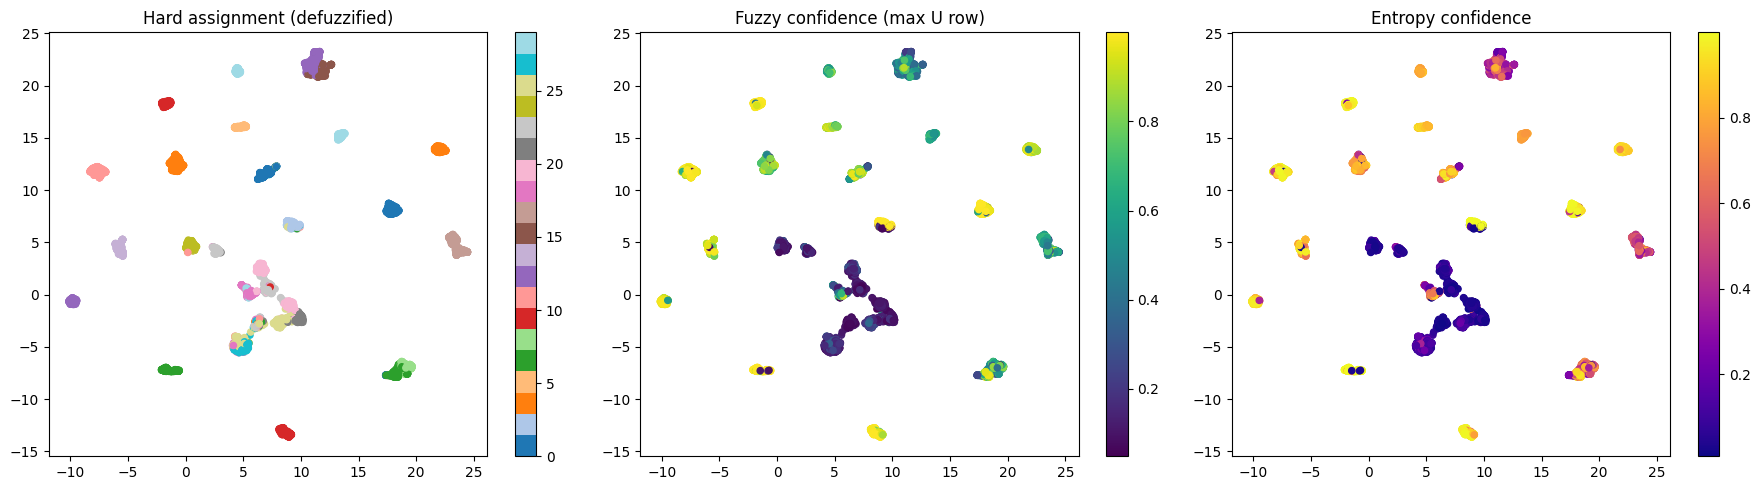

Visualization saved -> mol_cluster_viz.png


In [ ]:
import numpy as np
import hdbscan
import umap
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# LOAD EMBEDDINGS
# =========================
# CHANGE: Removed reaction_embeddings / rxn_gnn_artifacts.pkl loading.
# Reason: Source is now molecule_embeddings_paper.pkl — a dict of
#         {smiles_str: np.ndarray} produced by the TPT/Word2Vec pipeline.
#         There is no paired `dataset` DataFrame here (each node IS one
#         molecule identified by its SMILES key), so all dataset alignment
#         code has been removed.

EMBEDDING_PKL_PATH = "/content/molecule_embeddings_paper3.pkl"

print(f"Loading embeddings from {EMBEDDING_PKL_PATH} ...")
with open(EMBEDDING_PKL_PATH, "rb") as f:
    embedding_dict = pickle.load(f)

# Build parallel arrays: smiles list + embedding matrix
smiles_list = list(embedding_dict.keys())
emb         = np.array([embedding_dict[s] for s in smiles_list], dtype=np.float64)

print(f"Molecules loaded : {len(smiles_list):,}")
print(f"Embedding shape  : {emb.shape}")


# =========================
# NORMALISE EMBEDDING
# =========================

scaler_emb = StandardScaler()
emb_norm   = scaler_emb.fit_transform(emb)


# =========================
# UMAP
# =========================
# CHANGE: Removed random_state=42 from UMAP.
# Reason: random_state is not supported / causes errors in CPU-only
#         environments with some UMAP versions. Reproducibility is
#         traded for compatibility; re-run variance is minor at this
#         dimensionality.

print("Running UMAP for clustering space...")
reducer_cluster = umap.UMAP(
    n_components = 12,
    n_neighbors  = 15,
    min_dist     = 0.0,
    metric       = 'euclidean'
)
X_umap = reducer_cluster.fit_transform(emb_norm)
print(f"UMAP done -> shape: {X_umap.shape}")


# =========================
# HDBSCAN  (fixed params — no Optuna)
# =========================
# CHANGE: Removed Optuna hyperparameter search entirely.
# Reason: Optuna adds significant runtime and requires GPU-friendly
#         parallelism to be practical; on CPU it is slow and the
#         benefit over sensible fixed defaults is marginal.
#         Defaults below are chosen conservatively for a ~100k-node
#         molecule graph:
#           min_cluster_size = 30  — avoids micro-clusters
#           min_samples      = 10  — moderate noise robustness
#         Adjust these two values if you want fewer/larger clusters.

MAX_CLUSTERS     = 30
MIN_CLUSTER_SIZE = 30   # tune: larger → fewer, bigger clusters
MIN_SAMPLES      = 10   # tune: larger → more points labelled noise

print(f"\nRunning HDBSCAN  (min_cluster_size={MIN_CLUSTER_SIZE}, "
      f"min_samples={MIN_SAMPLES}) ...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size         = MIN_CLUSTER_SIZE,
    min_samples              = MIN_SAMPLES,
    cluster_selection_method = 'leaf',
    metric                   = 'euclidean'
)
labels = clusterer.fit_predict(X_umap)

n_clusters_raw = len(set(labels)) - (1 if -1 in labels else 0)
noise_count    = np.sum(labels == -1)
print(f"Clusters found : {n_clusters_raw} | Noise points : {noise_count}")

# Hard-enforce MAX_CLUSTERS — keep largest N clusters, demote rest to noise
if n_clusters_raw > MAX_CLUSTERS:
    print(f"  {n_clusters_raw} clusters exceeds MAX_CLUSTERS={MAX_CLUSTERS}. "
          f"Merging smallest...")
    unique_raw, counts_raw = np.unique(labels[labels != -1], return_counts=True)
    keep     = unique_raw[np.argsort(counts_raw)[::-1][:MAX_CLUSTERS]]
    keep_set = set(keep)
    labels   = np.array([l if l in keep_set else -1 for l in labels])
    noise_count = np.sum(labels == -1)
    print(f"  After merge : {MAX_CLUSTERS} clusters | Noise points : {noise_count}")

# Remove noise points
# CHANGE: Removed dataset.iloc[mask] alignment.
# Reason: Identity is tracked via smiles_list (parallel to emb), not a
#         DataFrame. We apply the same boolean mask to smiles_list instead.
mask        = labels != -1
emb         = emb[mask]
X_umap      = X_umap[mask]
smiles_list = [s for s, m in zip(smiles_list, mask) if m]
labels      = labels[mask]

# Re-fit scaler on clean data
emb_norm = scaler_emb.fit_transform(emb)

unique_clusters = np.unique(labels)
n_clusters      = len(unique_clusters)
print(f"Molecules after noise removal : {len(emb):,} | Clusters : {n_clusters}")


# =========================
# CENTROIDS
# =========================

C_emb = np.array([emb_norm[labels == c].mean(axis=0) for c in unique_clusters])


# =========================
# DISTANCE HELPERS
# =========================

def cosine_distance(X, C):
    return 1.0 - cosine_similarity(X, C)


def normalize_per_cluster(D, epsilon=1e-8):
    col_means = D.mean(axis=0, keepdims=True)
    return D / (col_means + epsilon)


m       = 1.8
epsilon = 1e-8
power   = 2.0 / (m - 1)


# =========================
# FCM LOOP (EMBEDDING-ONLY)
# =========================

for iteration in range(30):
    d_emb = cosine_distance(emb_norm, C_emb)

    dist = normalize_per_cluster(d_emb, epsilon)
    dist = np.clip(dist, epsilon, None)

    ratio = dist[:, :, None] / (dist[:, None, :] + epsilon)
    U     = 1.0 / np.sum(ratio ** power, axis=2)

    U_m = U ** m

    prev_C_emb = C_emb.copy()

    weights = U_m.sum(axis=0)[:, None] + epsilon
    C_emb   = (U_m.T @ emb_norm) / weights

    shift = np.linalg.norm(C_emb - prev_C_emb)
    if shift < 1e-4:
        print(f"Fuzzy converged at iteration {iteration}  (centroid shift={shift:.2e})")
        break


# =========================
# OUTPUT
# =========================

confidence         = np.max(U, axis=1)
entropy            = -np.sum(U * np.log(U + epsilon), axis=1)
confidence_entropy = 1.0 - entropy / np.log(n_clusters)
hard_assignment    = np.argmax(U, axis=1)

print(f"\nU matrix shape : {U.shape}")
print(f"Mean confidence        : {confidence.mean():.3f}")
print(f"Mean entropy-conf      : {confidence_entropy.mean():.3f}")


# =========================
# SAVE
# =========================

CLUSTER_SAVE_PATH = "mol_cluster_artifacts.pkl"

cluster_artifacts = {
    # CHANGE: replaced dataset_index with smiles_list.
    # Reason: molecule identity is the SMILES string, not a DataFrame row index.
    "smiles_list":        smiles_list,
    "U":                  U,
    "C_emb":              C_emb,
    "hard_assignment":    hard_assignment,
    "confidence":         confidence,
    "confidence_entropy": confidence_entropy,
    "unique_clusters":    unique_clusters,
    # CHANGE: removed hdbscan_best_params (Optuna) — store fixed params instead.
    "hdbscan_params": {
        "min_cluster_size":         MIN_CLUSTER_SIZE,
        "min_samples":              MIN_SAMPLES,
        "cluster_selection_method": "leaf",
        "metric":                   "euclidean",
    },
    "fcm_m":       m,
    "fcm_power":   power,
    "fcm_epsilon": epsilon,
    "scaler_emb":  scaler_emb,
    "emb":         emb,
    "emb_norm":    emb_norm,
    "n_clusters":  n_clusters,
}

with open(CLUSTER_SAVE_PATH, "wb") as f:
    pickle.dump(cluster_artifacts, f, protocol=4)

print(f"\nCluster artifacts saved -> {CLUSTER_SAVE_PATH}")


# =========================
# VISUALIZE
# =========================
# CHANGE: Removed random_state=42 from visualization UMAP (same reason as above).

reducer_viz = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
emb_2d      = reducer_viz.fit_transform(emb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc0 = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=hard_assignment,    cmap="tab20",  s=20)
axes[0].set_title("Hard assignment (defuzzified)")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=confidence,         cmap="viridis", s=20)
axes[1].set_title("Fuzzy confidence (max U row)")
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(emb_2d[:, 0], emb_2d[:, 1], c=confidence_entropy, cmap="plasma",  s=20)
axes[2].set_title("Entropy confidence")
plt.colorbar(sc2, ax=axes[2])

plt.tight_layout()
plt.savefig("mol_cluster_viz.png", dpi=150)
plt.show()
print("Visualization saved -> mol_cluster_viz.png")

In [ ]:
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity

# CHANGE: Removed ARTIFACTS_PATH (rxn_gnn_artifacts.pkl) — not needed.
# Reason: We have no reaction dataset; identity is SMILES strings from cluster pkl.

CLUSTER_ARTIFACTS_PATH = "mol_cluster_artifacts.pkl"

# =========================
# LOAD CLUSTER ARTIFACTS
# =========================
# CHANGE: Removed in-memory try/except for `U` — no notebook chain assumed.
# CHANGE: Replaced dataset_index + dataset.iloc[...] with smiles_list.
# Reason: Cluster artifacts now store smiles_list (parallel to emb/U rows),
#         not a DataFrame row index. No dataset exists to re-slice.

print(f"Loading cluster artifacts from {CLUSTER_ARTIFACTS_PATH} ...")
with open(CLUSTER_ARTIFACTS_PATH, "rb") as f:
    _c = pickle.load(f)

U                  = _c["U"]
C_emb              = _c["C_emb"]
hard_assignment    = _c["hard_assignment"]
confidence         = _c["confidence"]
confidence_entropy = _c["confidence_entropy"]
unique_clusters    = _c["unique_clusters"]
scaler_emb         = _c["scaler_emb"]
emb                = _c["emb"]
emb_norm           = _c["emb_norm"]
n_clusters         = _c["n_clusters"]
smiles_list        = _c["smiles_list"]          # list[str], len == U.shape[0]

print(f"Loaded: {len(smiles_list):,} molecules, {n_clusters} clusters")
print(f"U matrix shape: {U.shape}")

n_molecules  = U.shape[0]
hard_labels  = np.argmax(U, axis=1)


# =========================
# CLUSTER PROFILES
# =========================
# CHANGE: Removed mechanistic profile block (delta_rings, delta_charge,
#         bonds_broken, bonds_formed, delta_fg) entirely.
# Reason: These were reaction-level DataFrame columns. Molecule nodes have
#         no such attributes. Profiles are rebuilt from what we DO have:
#         embedding geometry (intra-cluster cosine compactness) and
#         fuzzy membership statistics.

cluster_profiles = {}

for k in range(n_clusters):
    mask_hard = hard_labels == k
    count     = int(mask_hard.sum())
    if count == 0:
        continue

    weights  = U[:, k]
    w_norm   = weights / (weights.sum() + 1e-8)

    # Fuzzy centroid in normalised embedding space (already computed as C_emb)
    centroid = C_emb[k]

    # Intra-cluster cosine compactness: mean cosine sim of members to centroid
    member_vecs  = emb_norm[mask_hard]
    c_unit       = centroid / (np.linalg.norm(centroid) + 1e-8)
    m_norms      = np.linalg.norm(member_vecs, axis=1, keepdims=True)
    m_unit       = member_vecs / (m_norms + 1e-8)
    cos_to_cent  = float((m_unit @ c_unit).mean())

    # Weighted mean confidence of ALL molecules toward this cluster
    mean_conf_all  = float(weights.mean())
    # Mean confidence of hard-assigned members only
    mean_conf_hard = float(np.max(U[mask_hard], axis=1).mean()) if count > 0 else 0.0

    # Top-5 most confidently assigned SMILES (hard members, ranked by U[:,k])
    hard_indices = np.where(mask_hard)[0]
    top5_idx     = hard_indices[np.argsort(U[hard_indices, k])[::-1][:5]]
    top5_smiles  = [smiles_list[i] for i in top5_idx]
    top5_conf    = [float(U[i, k]) for i in top5_idx]

    cluster_profiles[k] = {
        "cluster_size":        count,
        "mean_confidence":     mean_conf_hard,
        "mean_confidence_all": mean_conf_all,
        "cosine_compactness":  cos_to_cent,       # 1.0 = perfectly tight cluster
        "top5_smiles":         top5_smiles,
        "top5_confidence":     top5_conf,
    }

print(f"Profiles built for {len(cluster_profiles)} clusters.")


# =========================
# INTER-CLUSTER SIMILARITY MATRIX
# =========================
# CHANGE: Replaces auto_name_cluster / REACTION_TEMPLATES / text embeddings.
# Reason: Those relied on functional-group delta columns and free-text notes
#         from the reaction dataset. Instead, we compute pairwise cosine
#         similarity between cluster centroids in embedding space, which
#         reveals which clusters are geometrically close / redundant.

C_norms    = np.linalg.norm(C_emb, axis=1, keepdims=True)
C_unit     = C_emb / (C_norms + 1e-8)
sim_matrix = cosine_similarity(C_unit)           # shape (n_clusters, n_clusters)

# For each cluster: which other cluster is closest?
cluster_nearest = {}
for k in range(n_clusters):
    sims_k = sim_matrix[k].copy()
    sims_k[k] = -1.0                            # exclude self
    nearest   = int(np.argmax(sims_k))
    cluster_nearest[k] = (nearest, float(sim_matrix[k, nearest]))

print("Inter-cluster similarity matrix computed.")


# =========================
# PRINT CLUSTER REPORTS
# =========================
# CHANGE: Removed mechanistic summary rows (ΔRings, Bonds etc.) and
#         representative notes (no notes column).
# Reason: Not available. Replaced with embedding-space geometry stats
#         and top-5 representative SMILES by membership confidence.

DIVIDER      = "=" * 70
THIN_DIVIDER = "-" * 70

for cluster_id in sorted(cluster_profiles.keys()):
    prof    = cluster_profiles[cluster_id]
    nearest, near_sim = cluster_nearest[cluster_id]

    print(f"\n{DIVIDER}")
    print(f"Cluster {cluster_id:>3}")
    print(f"  Size            : {prof['cluster_size']:,} molecules")
    print(f"  Confidence (hard members) : {prof['mean_confidence']:.4f}")
    print(f"  Confidence (all, fuzzy)   : {prof['mean_confidence_all']:.4f}")
    print(f"  Cosine compactness        : {prof['cosine_compactness']:.4f}  "
          f"(1=tight, 0=diffuse)")
    print(f"  Nearest cluster           : {nearest}  "
          f"(cosine sim = {near_sim:.4f})")
    print(f"\n  Top-5 representative SMILES (by membership confidence):")
    for rank, (smi, conf) in enumerate(
            zip(prof["top5_smiles"], prof["top5_confidence"]), 1):
        print(f"    [{rank}]  conf={conf:.4f}  {smi[:90]}")

    print()


# =========================
# CROSS-CLUSTER SUMMARY TABLE
# =========================

print("\n" + DIVIDER)
print("CROSS-CLUSTER SUMMARY")
print(DIVIDER)

header = (f"{'ID':>4}  {'N':>7}  {'Conf(hard)':>10}  "
          f"{'Compactness':>11}  {'Nearest':>7}  {'NearSim':>7}")
print(header)
print(THIN_DIVIDER)

for cluster_id in sorted(cluster_profiles.keys()):
    prof              = cluster_profiles[cluster_id]
    nearest, near_sim = cluster_nearest[cluster_id]

    print(
        f"{cluster_id:>4}  "
        f"{prof['cluster_size']:>7,}  "
        f"{prof['mean_confidence']:>10.4f}  "
        f"{prof['cosine_compactness']:>11.4f}  "
        f"{nearest:>7}  "
        f"{near_sim:>7.4f}"
    )

print(THIN_DIVIDER)
print(f"Total clusters : {n_clusters}")


# =========================
# SAVE
# =========================
# CHANGE: Renamed save path to mol_xai_artifacts.pkl.
# CHANGE: Removed cluster_mechanistic_profiles, cluster_names,
#         cluster_note_centroids, cluster_top_note_indices, notes.
# Reason: All depend on the reaction dataset. Replaced with
#         cluster_profiles (geometry + membership stats) and
#         sim_matrix / cluster_nearest (inter-cluster relations).

XAI_SAVE_PATH = "mol_xai_artifacts.pkl"

xai_artifacts = {
    "cluster_profiles":  cluster_profiles,
    "sim_matrix":        sim_matrix,
    "cluster_nearest":   cluster_nearest,
    "n_clusters":        n_clusters,
    "smiles_list":       smiles_list,
    "hard_labels":       hard_labels,
    "U":                 U,
}

with open(XAI_SAVE_PATH, "wb") as f:
    pickle.dump(xai_artifacts, f, protocol=4)

print(f"\nXAI artifacts saved -> {XAI_SAVE_PATH}")

Loading cluster artifacts from mol_cluster_artifacts.pkl ...
Loaded: 7,658 molecules, 30 clusters
U matrix shape: (7658, 30)
Profiles built for 30 clusters.
Inter-cluster similarity matrix computed.

Cluster   0
  Size            : 194 molecules
  Confidence (hard members) : 0.8004
  Confidence (all, fuzzy)   : 0.0357
  Cosine compactness        : 0.9044  (1=tight, 0=diffuse)
  Nearest cluster           : 3  (cosine sim = 0.9243)

  Top-5 representative SMILES (by membership confidence):
    [1]  conf=0.9848  Nn1[nH]o1
    [2]  conf=0.9796  CCCC(O)(O)CO
    [3]  conf=0.9787  C=C(O)C(=C)C(C)C
    [4]  conf=0.9763  CON(C)C(C)C
    [5]  conf=0.9763  CC(C)C(=O)CCCN


Cluster   1
  Size            : 317 molecules
  Confidence (hard members) : 0.9289
  Confidence (all, fuzzy)   : 0.0472
  Cosine compactness        : 0.9404  (1=tight, 0=diffuse)
  Nearest cluster           : 13  (cosine sim = 0.3634)

  Top-5 representative SMILES (by membership confidence):
    [1]  conf=0.9997  CCC(C)NNO
  